In [20]:
import json

kaggle_dict = {
    "username": "ipl",
    "key": "KGAT_c24c6a7838bde2e3a828ff7b43050f56"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

print("✅ kaggle.json created")

✅ kaggle.json created


In [21]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [22]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          20482        442                1  
prince7489/online-vs-offline-learning-efficiency-dataset            Online vs Offline Learning Efficiency Dataset             7365  2026-05-02 16:38:31.343000            966         25        0.9411765  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           1949         52

In [23]:
!kaggle datasets download -d patrickb1912/ipl-complete-dataset-20082020 --unzip -p /content/ipl_data/
!kaggle datasets download -d manasgarg/ipl --unzip -p /content/ipl_data/

Dataset URL: https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020
License(s): DbCL-1.0
100% 1.82M/1.82M [00:00<00:00, 59.6MB/s]

Dataset URL: https://www.kaggle.com/datasets/manasgarg/ipl
License(s): CC-BY-NC-SA-4.0
100% 1.01M/1.01M [00:00<00:00, 98.2MB/s]



In [24]:
import os
os.listdir('/content/ipl_data')

['matches.csv', 'deliveries.csv']

In [27]:
!pip install streamlit -q

In [29]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics         import (accuracy_score, classification_report,
                                     confusion_matrix, roc_auc_score,
                                     roc_curve, ConfusionMatrixDisplay)
from sklearn.decomposition   import PCA

In [30]:
try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    XGBOOST_OK = False
    print("⚠️  XGBoost not found — using GradientBoostingClassifier as substitute.")

warnings.filterwarnings("ignore")


In [31]:
DATA_ROOTS   = ["/content/ipl_data", "./ipl_data", "."]
MODEL_DIR    = "./ipl_models"
PLOT_DIR     = "./ipl_plots"
RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_CLUSTERS   = 4

In [32]:
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,  exist_ok=True)

In [33]:
PALETTE = ["#4fc3f7", "#e91e63", "#66bb6a", "#ff9800",
           "#ab47bc", "#ef5350", "#26c6da", "#ffca28"]

print("=" * 65)
print("  IPL SPORTS ANALYTICS — MODEL TRAINING PIPELINE")
print("=" * 65)

  IPL SPORTS ANALYTICS — MODEL TRAINING PIPELINE


In [35]:
def find_csv(candidates: list[str], roots: list[str]) -> pd.DataFrame | None:
    for root in roots:
        for name in candidates:
            p = os.path.join(root, name)
            if os.path.exists(p):
                print(f"  ✔ Found: {p}")
                return pd.read_csv(p)
    return None

In [36]:
def generate_synthetic_data(n_matches: int = 950, seed: int = RANDOM_STATE):
    """
    Generate realistic synthetic IPL data that mirrors the Kaggle schema.
    Used automatically when real CSVs are absent.
    """
    print("\n  ⚡ Real data not found → generating synthetic IPL dataset …")
    rng = np.random.default_rng(seed)

    TEAMS = [
        "Mumbai Indians", "Chennai Super Kings",
        "Royal Challengers Bangalore", "Kolkata Knight Riders",
        "Sunrisers Hyderabad", "Delhi Capitals",
        "Punjab Kings", "Rajasthan Royals",
        "Gujarat Titans", "Lucknow Super Giants",
    ]
    VENUES = [
        "Wankhede Stadium", "M Chinnaswamy Stadium", "Eden Gardens",
        "MA Chidambaram Stadium", "Arun Jaitley Stadium",
        "Rajiv Gandhi Intl Stadium", "Punjab Cricket Association IS Bindra Stadium",
        "Sawai Mansingh Stadium", "Narendra Modi Stadium", "DY Patil Stadium",
    ]
    SEASONS   = list(range(2008, 2025))
    PLAYERS   = [f"Player_{i:03d}" for i in range(1, 251)]
    RUN_PROBS = [0.30, 0.25, 0.15, 0.10, 0.08, 0.05, 0.07]  # 0–6 runs

    # ── Matches ──
    m_rows = []
    for mid in range(1, n_matches + 1):
        t1, t2   = rng.choice(TEAMS, size=2, replace=False)
        toss_w   = rng.choice([t1, t2])
        toss_d   = rng.choice(["bat", "field"])
        # slight toss advantage
        p_t1 = 0.54 if (toss_w == t1 and toss_d == "bat") else \
               0.52 if (toss_w == t1 and toss_d == "field") else 0.46
        winner = t1 if rng.random() < p_t1 else t2

        m_rows.append({
            "id": mid, "season": rng.choice(SEASONS),
            "city": rng.choice(VENUES), "venue": rng.choice(VENUES),
            "team1": t1, "team2": t2,
            "toss_winner": toss_w, "toss_decision": toss_d,
            "winner": winner,
            "player_of_match": rng.choice(PLAYERS),
            "result": "normal", "dl_applied": 0,
        })
    matches_df = pd.DataFrame(m_rows)

    # ── Deliveries ──
    d_rows = []
    for _, match in matches_df.iterrows():
        bat_first  = match["team1"] if match["toss_decision"] == "bat" else match["team2"]
        bat_second = match["team2"] if bat_first == match["team1"] else match["team1"]

        for innings, bat_team in enumerate([bat_first, bat_second], 1):
            bowl_team = bat_second if innings == 1 else bat_first
            batsmen   = rng.choice(PLAYERS, size=11, replace=False)
            bowlers   = rng.choice(PLAYERS, size=7,  replace=False)
            wkts = 0; cum_runs = 0

            for ball_num in range(120):
                if wkts >= 10: break
                ov  = ball_num // 6
                bl  = ball_num %  6 + 1
                btr = batsmen[min(wkts, 10)]
                bwl = bowlers[ov % len(bowlers)]

                bat_runs = int(rng.choice([0,1,2,3,4,5,6], p=RUN_PROBS))
                wide = noball = 0; extra = 0
                if rng.random() < 0.03: wide = 1; bat_runs = 0; extra = 1
                elif rng.random() < 0.02: noball = 1; extra = 1

                is_wkt = 0; dismissed = np.nan
                if rng.random() < 0.06 and not wide:
                    is_wkt = 1; dismissed = btr; wkts += 1

                cum_runs += bat_runs + extra
                d_rows.append({
                    "match_id": match["id"], "inning": innings,
                    "batting_team": bat_team, "bowling_team": bowl_team,
                    "over": ov, "ball": bl,
                    "batter": btr, "bowler": bwl,
                    "non_striker": batsmen[min(wkts+1, 10)],
                    "batsman_runs": bat_runs, "extra_runs": extra,
                    "total_runs": bat_runs + extra,
                    "extras_type": "wides" if wide else ("noballs" if noball else np.nan),
                    "is_wicket": is_wkt,
                    "player_dismissed": dismissed,
                    "dismissal_kind": "caught" if is_wkt else np.nan,
                })

    deliveries_df = pd.DataFrame(d_rows)
    print(f"  ✔ Synthetic data: {len(matches_df):,} matches | {len(deliveries_df):,} deliveries")
    return matches_df, deliveries_df

In [37]:
def load_data():
    print("\n[STEP 1] Loading Data")
    print("-" * 40)
    matches_df = find_csv(
        ["matches.csv", "IPL Matches 2008-2020.csv", "ipl_matches.csv"], DATA_ROOTS)
    deliveries_df = find_csv(
        ["deliveries.csv", "IPL Ball-by-Ball 2008-2020.csv", "ipl_deliveries.csv"], DATA_ROOTS)

    if matches_df is None or deliveries_df is None:
        matches_df, deliveries_df = generate_synthetic_data()

    # Normalise column names
    matches_df.columns    = [c.lower().replace(" ", "_") for c in matches_df.columns]
    deliveries_df.columns = [c.lower().replace(" ", "_") for c in deliveries_df.columns]

    if "match_id" in matches_df.columns and "id" not in matches_df.columns:
        matches_df.rename(columns={"match_id": "id"}, inplace=True)
    if "id" in deliveries_df.columns and "match_id" not in deliveries_df.columns:
        deliveries_df.rename(columns={"id": "match_id"}, inplace=True)

    matches_df.dropna(subset=["winner"], inplace=True)
    print(f"  ✔ Matches   : {len(matches_df):,} rows × {matches_df.shape[1]} cols")
    print(f"  ✔ Deliveries: {len(deliveries_df):,} rows × {deliveries_df.shape[1]} cols")
    return matches_df, deliveries_df

In [38]:
def build_match_features(matches_df: pd.DataFrame):
    """
    Match-level features for Logistic Regression & Random Forest.
    Returns X, y, feature names, and fitted label encoders.
    """
    print("\n[STEP 2a] Building Match-Level Features")
    print("-" * 40)
    df = matches_df.copy()
    encoders = {}
    cat_cols = ["team1", "team2", "toss_winner", "toss_decision", "venue"]

    for col in cat_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col + "_enc"] = le.fit_transform(df[col].astype(str))
            encoders[col] = le

    df["team1_win"] = (df["winner"] == df["team1"]).astype(int)

    feat_cols = [c + "_enc" for c in cat_cols if c + "_enc" in df.columns]
    X = df[feat_cols].fillna(0)
    y = df["team1_win"]

    print(f"  ✔ Features : {feat_cols}")
    print(f"  ✔ Samples  : {len(X):,}  |  Class balance: {y.mean()*100:.1f}% team1 wins")
    return X, y, feat_cols, encoders

In [76]:
def build_ball_by_ball_features(deliveries_df: pd.DataFrame,
                                 matches_df: pd.DataFrame):
    """
    Second-innings ball-by-ball features for XGBoost win-probability model.
    """
    print("\n[STEP 2b] Building Ball-by-Ball Features")
    print("-" * 40)
    # total_runs → numeric
    deliveries_df["total_runs"] = pd.to_numeric(deliveries_df["total_runs"], errors="coerce")

# player_dismissed → convert to 0/1 (IMPORTANT FIX)
    deliveries_df["player_dismissed"] = deliveries_df["player_dismissed"].notna().astype(int)

# ball & over → numeric
    deliveries_df["ball"] = pd.to_numeric(deliveries_df["ball"], errors="coerce")
    deliveries_df["over"] = pd.to_numeric(deliveries_df["over"], errors="coerce")

# Remove bad rows
    deliveries_df.dropna(subset=["total_runs", "ball", "over"], inplace=True)
    # First-innings totals
    inn1 = (deliveries_df[deliveries_df["inning"] == 1]
            .groupby("match_id")["total_runs"].sum()
            .reset_index()
            .rename(columns={"total_runs": "first_innings_total"}))

    # Second innings
    inn2 = (deliveries_df[deliveries_df["inning"] == 2]
            .copy()
            .sort_values(["match_id", "over", "ball"]))

    inn2["cum_runs"]    = inn2.groupby("match_id")["total_runs"].cumsum()
    inn2["cum_wickets"] = inn2.groupby("match_id")["player_dismissed"].cumsum()
    inn2["balls_done"]  = inn2.groupby("match_id").cumcount() + 1
    inn2["overs_done"]  = (inn2["balls_done"] - 1) // 6
    inn2["balls_left"]  = (120 - inn2["balls_done"]).clip(lower=0)
    inn2["overs_left"]  = inn2["balls_left"] / 6

    inn2 = inn2.merge(inn1, on="match_id", how="left")
    inn2["runs_needed"]     = (inn2["first_innings_total"] + 1 - inn2["cum_runs"]).clip(lower=0)
    inn2["rrr"]             = np.where(inn2["balls_left"] > 0,
                                        inn2["runs_needed"] / (inn2["balls_left"] / 6), 0)
    inn2["current_rr"]      = np.where(inn2["balls_done"] > 0,
                                        inn2["cum_runs"] / (inn2["balls_done"] / 6), 0)
    inn2["wickets_in_hand"] = (10 - inn2["cum_wickets"]).clip(lower=0)
    inn2["run_rate_diff"]   = inn2["current_rr"] - inn2["rrr"]    # positive → batting team ahead
    inn2["balls_per_wicket"]= np.where(inn2["cum_wickets"] > 0,
                                        inn2["balls_done"] / inn2["cum_wickets"], 120)

    # Labels
    outcome = (matches_df[["id", "winner"]]
               .rename(columns={"id": "match_id"})
               .merge(inn2[["match_id","batting_team"]].drop_duplicates("match_id"),
                      on="match_id", how="left"))
    outcome["batting_wins"] = (outcome["winner"] == outcome["batting_team"]).astype(int)
    inn2 = inn2.merge(outcome[["match_id","batting_wins"]], on="match_id", how="left")
    inn2.dropna(subset=["batting_wins","first_innings_total","rrr"], inplace=True)

    FEATURES = [
        "first_innings_total", "cum_runs", "cum_wickets",
        "overs_done", "overs_left", "runs_needed",
        "rrr", "current_rr", "wickets_in_hand",
        "run_rate_diff", "balls_per_wicket",
    ]
    X = inn2[FEATURES].fillna(0)
    y = inn2["batting_wins"].astype(int)

    print(f"  ✔ Features : {FEATURES}")
    print(f"  ✔ Samples  : {len(X):,}  |  Class balance: {y.mean()*100:.1f}% batting team wins")
    return X, y, FEATURES

In [88]:
def build_player_features(deliveries_df: pd.DataFrame):
    """
    Career batting features for K-Means clustering.
    """
    print("\n[STEP 2c] Building Player Clustering Features")
    print("-" * 40)

    bat = deliveries_df[deliveries_df["inning"].isin([1, 2])].copy()
    per_match = bat.groupby(["match_id", "batsman"]).agg(
        runs  =("batsman_runs", "sum"),
        balls =("ball", "count"),
        fours =("batsman_runs", lambda x: (x == 4).sum()),
        sixes =("batsman_runs", lambda x: (x == 6).sum()),
    ).reset_index()

    career = per_match.groupby("batsman").agg(
        total_runs    =("runs",   "sum"),
        avg_runs      =("runs",   "mean"),
        avg_balls     =("balls",  "mean"),
        avg_fours     =("fours",  "mean"),
        avg_sixes     =("sixes",  "mean"),
        innings       =("match_id","nunique"),
    ).reset_index()

    career["strike_rate"]    = np.where(career["avg_balls"] > 0,
                                         career["avg_runs"] / career["avg_balls"] * 100, 0)
    career["boundary_ratio"] = np.where(career["avg_balls"] > 0,
                                         (career["avg_fours"] + career["avg_sixes"]) / career["avg_balls"], 0)
    career["consistency"]    = career["avg_runs"] / (career["avg_runs"].std() + 1e-6)

    career = career[career["innings"] >= 3].reset_index(drop=True)
    FEATURES = ["avg_runs", "strike_rate", "avg_fours", "avg_sixes",
                "boundary_ratio", "consistency"]
    print(f"  ✔ Features : {FEATURES}")
    print(f"  ✔ Eligible players: {len(career):,}")
    return career, FEATURES

Model 1:Logistic regression

In [89]:
def train_logistic_regression(X, y, feat_cols, encoders):
    print("\n" + "=" * 65)
    print("  MODEL 1 — LOGISTIC REGRESSION (Baseline Win Predictor)")
    print("=" * 65)
    t0 = time.time()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model = LogisticRegression(max_iter=1000, C=1.0,
                                solver="lbfgs", random_state=RANDOM_STATE)
    model.fit(X_tr_s, y_tr)

    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]
    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, y_prob)

    # Cross-validation
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_acc = cross_val_score(model, X_tr_s, y_tr, cv=cv, scoring="accuracy")

    print(f"\n  Accuracy       : {acc*100:.2f}%")
    print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  CV Accuracy    : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")
    print(f"  Training time  : {time.time()-t0:.2f}s")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Team2 Wins','Team1 Wins'])}")

    # ── Plots ──
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Logistic Regression — Evaluation", fontsize=14, color="#4fc3f7")

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Team2 Win","Team1 Win"]).plot(
        ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title("Confusion Matrix", color="#4fc3f7")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[1].plot(fpr, tpr, color="#4fc3f7", lw=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0,1],[0,1],"--", color="#666")
    axes[1].set(title="ROC Curve", xlabel="FPR", ylabel="TPR")
    axes[1].set_title("ROC Curve", color="#4fc3f7")
    axes[1].legend()

    # Feature coefficients
    coef_df = pd.DataFrame({"feature": feat_cols, "coeff": model.coef_[0]})
    coef_df = coef_df.sort_values("coeff")
    axes[2].barh(coef_df["feature"], coef_df["coeff"],
                 color=[PALETTE[0] if c > 0 else PALETTE[1] for c in coef_df["coeff"]])
    axes[2].set_title("Feature Coefficients", color="#4fc3f7")
    axes[2].axvline(0, color="white", lw=0.8)

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "1_logistic_regression.png")
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  📊 Plot saved → {path}")

    # Save
    artifacts = {"model": model, "scaler": scaler, "features": feat_cols,
                 "encoders": encoders, "accuracy": acc, "auc": auc}
    joblib.dump(artifacts, os.path.join(MODEL_DIR, "logistic_regression.pkl"))
    print(f"  💾 Model saved → {MODEL_DIR}/logistic_regression.pkl")
    return artifacts

Model 2:Random forest


In [90]:
def train_random_forest(X, y, feat_cols, encoders):
    print("\n" + "=" * 65)
    print("  MODEL 2 — RANDOM FOREST (Non-linear Match Predictor)")
    print("=" * 65)
    t0 = time.time()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

    model = RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, max_features="sqrt",
        n_jobs=-1, random_state=RANDOM_STATE, oob_score=True)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, y_prob)
    oob    = model.oob_score_

    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_acc = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="accuracy")

    print(f"\n  Accuracy       : {acc*100:.2f}%")
    print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  OOB Score      : {oob*100:.2f}%")
    print(f"  CV Accuracy    : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")
    print(f"  Training time  : {time.time()-t0:.2f}s")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Team2 Wins','Team1 Wins'])}")

    # ── Plots ──
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Random Forest — Evaluation", fontsize=14, color="#4fc3f7")

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Team2 Win","Team1 Win"]).plot(
        ax=axes[0], colorbar=False, cmap="Greens")
    axes[0].set_title("Confusion Matrix", color="#4fc3f7")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[1].plot(fpr, tpr, color="#66bb6a", lw=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0,1],[0,1],"--", color="#666")
    axes[1].set(title="ROC Curve", xlabel="FPR", ylabel="TPR")
    axes[1].set_title("ROC Curve", color="#4fc3f7")
    axes[1].legend()

    # Feature importance
    fi = pd.DataFrame({"feature": feat_cols,
                        "importance": model.feature_importances_}).sort_values("importance")
    axes[2].barh(fi["feature"], fi["importance"], color=PALETTE[2])
    axes[2].set_title("Feature Importance", color="#4fc3f7")

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "2_random_forest.png")
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  📊 Plot saved → {path}")

    artifacts = {"model": model, "features": feat_cols, "encoders": encoders,
                 "accuracy": acc, "auc": auc, "oob_score": oob}
    joblib.dump(artifacts, os.path.join(MODEL_DIR, "random_forest.pkl"))
    print(f"  💾 Model saved → {MODEL_DIR}/random_forest.pkl")
    return artifacts

model3:XGboost

In [91]:
def train_xgboost(X, y, feat_cols):
    label = "XGBoost" if XGBOOST_OK else "GradientBoosting (XGBoost substitute)"
    print("\n" + "=" * 65)
    print(f"  MODEL 3 — {label} (Real-Time Win Probability)")
    print("=" * 65)
    t0 = time.time()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    if XGBOOST_OK:
        model = XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=3, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0,
            use_label_encoder=False, eval_metric="logloss",
            random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
        model.fit(X_tr_s, y_tr,
                  eval_set=[(X_te_s, y_te)],
                  verbose=False)
    else:
        from sklearn.ensemble import GradientBoostingClassifier
        model = GradientBoostingClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.08,
            subsample=0.8, random_state=RANDOM_STATE)
        model.fit(X_tr_s, y_tr)

    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]
    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, y_prob)

    print(f"\n  Accuracy       : {acc*100:.2f}%")
    print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  Training time  : {time.time()-t0:.2f}s")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Bowling Wins','Batting Wins'])}")

    # Win probability curve at different match states
    overs_range = np.linspace(0, 19, 50)
    demo_states = pd.DataFrame({
        "first_innings_total": [170] * 50,
        "cum_runs":            np.linspace(0, 170, 50),
        "cum_wickets":         np.clip(np.linspace(0, 8, 50), 0, 9),
        "overs_done":          overs_range,
        "overs_left":          (20 - overs_range),
        "runs_needed":         np.linspace(170, 0, 50),
        "rrr":                 np.linspace(8.5, 0, 50),
        "current_rr":          np.linspace(0, 10, 50),
        "wickets_in_hand":     np.clip(10 - np.linspace(0, 8, 50), 1, 10),
        "run_rate_diff":       np.linspace(-8, 10, 50),
        "balls_per_wicket":    np.linspace(120, 15, 50),
    })[feat_cols]
    demo_probs = model.predict_proba(scaler.transform(demo_states))[:, 1] * 100

    # ── Plots ──
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"{label} — Evaluation Dashboard", fontsize=14, color="#4fc3f7")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[0,0].plot(fpr, tpr, color="#ff9800", lw=2.5, label=f"AUC = {auc:.3f}")
    axes[0,0].plot([0,1],[0,1],"--", color="#666")
    axes[0,0].set(title="ROC Curve", xlabel="FPR", ylabel="TPR")
    axes[0,0].set_title("ROC Curve", color="#4fc3f7")
    axes[0,0].legend()

    # Feature importance
    if XGBOOST_OK:
        fi_vals = model.feature_importances_
    else:
        fi_vals = model.feature_importances_
    fi = pd.DataFrame({"feature": feat_cols, "importance": fi_vals}).sort_values("importance")
    axes[0,1].barh(fi["feature"], fi["importance"], color=PALETTE[3])
    axes[0,1].set_title("Feature Importance", color="#4fc3f7")

    # Win probability curve
    axes[1,0].plot(overs_range, demo_probs, color="#4fc3f7", lw=2.5)
    axes[1,0].axhline(50, color="#666", linestyle="--", lw=1)
    axes[1,0].fill_between(overs_range, demo_probs, 50,
                            where=(demo_probs >= 50),
                            alpha=0.25, color="#66bb6a", label="Batting team ahead")
    axes[1,0].fill_between(overs_range, demo_probs, 50,
                            where=(demo_probs < 50),
                            alpha=0.25, color="#e91e63", label="Bowling team ahead")
    axes[1,0].set(title="Win Probability Curve (Demo Chase: 170)",
                   xlabel="Over", ylabel="Win Probability (%)", ylim=[0,100])
    axes[1,0].set_title("Win Probability Curve", color="#4fc3f7")
    axes[1,0].legend()

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Bowling Wins","Batting Wins"]).plot(
        ax=axes[1,1], colorbar=False, cmap="Oranges")
    axes[1,1].set_title("Confusion Matrix", color="#4fc3f7")

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "3_xgboost.png")
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  📊 Plot saved → {path}")

    artifacts = {"model": model, "scaler": scaler, "features": feat_cols,
                 "accuracy": acc, "auc": auc}
    joblib.dump(artifacts, os.path.join(MODEL_DIR, "xgboost.pkl"))
    print(f"  💾 Model saved → {MODEL_DIR}/xgboost.pkl")
    return artifacts

model 4:K-mean clustering

In [92]:
CLUSTER_LABELS = {0: "⚡ Power Hitter", 1: "🛡️ Anchor",
                  2: "🎯 Finisher",     3: "🔰 All-Rounder"}

def train_kmeans(career_df: pd.DataFrame, feat_cols: list[str]):
    print("\n" + "=" * 65)
    print("  MODEL 4 — K-MEANS CLUSTERING (Player Role Segmentation)")
    print("=" * 65)
    t0 = time.time()

    X_raw = career_df[feat_cols].fillna(0)
    scaler = StandardScaler()
    X_s    = scaler.fit_transform(X_raw)

    # ── Elbow method ──
    print("\n  Running Elbow method (k = 2 … 10) …")
    inertias = []
    for k in range(2, 11):
        km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km_tmp.fit(X_s)
        inertias.append(km_tmp.inertia_)

    # ── Final model ──
    model = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE,
                   n_init=20, max_iter=500)
    labels = model.fit_predict(X_s)

    career_df = career_df.copy()
    career_df["cluster"] = labels
    career_df["role"]    = career_df["cluster"].map(CLUSTER_LABELS)

    # PCA for 2-D visualisation
    pca    = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X_s)
    career_df["PC1"] = coords[:, 0]
    career_df["PC2"] = coords[:, 1]

    sil_approx = model.inertia_      # lower = tighter clusters
    print(f"\n  Inertia        : {sil_approx:,.1f}")
    print(f"  Training time  : {time.time()-t0:.2f}s")

    # Cluster summary
    print("\n  Cluster Summary:")
    summary = career_df.groupby("role")[feat_cols].mean().round(2)
    print(summary.to_string())

    # ── Plots ──
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("K-Means — Player Role Clustering", fontsize=14, color="#4fc3f7")

    # Elbow
    axes[0,0].plot(range(2,11), inertias, "o-", color="#4fc3f7", lw=2)
    axes[0,0].axvline(N_CLUSTERS, color="#e91e63", lw=1.5, linestyle="--",
                       label=f"k = {N_CLUSTERS}")
    axes[0,0].set(title="Elbow Method", xlabel="Number of Clusters (k)",
                   ylabel="Inertia")
    axes[0,0].set_title("Elbow Method", color="#4fc3f7")
    axes[0,0].legend()

    # PCA scatter
    colors_map = {v: PALETTE[i] for i, v in CLUSTER_LABELS.items()}
    for role, grp in career_df.groupby("role"):
        axes[0,1].scatter(grp["PC1"], grp["PC2"], alpha=0.6, s=18,
                           color=colors_map.get(role, "#aaa"), label=role)
    axes[0,1].set(title="PCA 2-D Projection", xlabel="PC1", ylabel="PC2")
    axes[0,1].set_title("PCA 2-D Projection", color="#4fc3f7")
    axes[0,1].legend(fontsize=8)

    # Role distribution
    role_counts = career_df["role"].value_counts()
    axes[1,0].bar(role_counts.index, role_counts.values,
                  color=[colors_map.get(r, "#aaa") for r in role_counts.index])
    axes[1,0].set_title("Player Role Distribution", color="#4fc3f7")
    axes[1,0].set_xticklabels(role_counts.index, rotation=20, ha="right")

    # Radar-like: cluster centroids as bar chart
    centroid_df = career_df.groupby("role")[feat_cols].mean()
    centroid_df.T.plot(kind="bar", ax=axes[1,1], color=list(colors_map.values()))
    axes[1,1].set_title("Cluster Centroid Comparison", color="#4fc3f7")
    axes[1,1].tick_params(axis="x", rotation=30)
    axes[1,1].legend(fontsize=8)

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "4_kmeans_clustering.png")
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  📊 Plot saved → {path}")

    artifacts = {"model": model, "scaler": scaler, "features": feat_cols,
                 "player_clusters": career_df, "pca": pca,
                 "inertia": sil_approx, "cluster_labels": CLUSTER_LABELS}
    joblib.dump(artifacts, os.path.join(MODEL_DIR, "kmeans.pkl"))
    print(f"  💾 Model saved → {MODEL_DIR}/kmeans.pkl")
    return artifacts

In [93]:
def print_summary(lr_art, rf_art, xgb_art):
    print("\n" + "=" * 65)
    print("  FINAL MODEL COMPARISON SUMMARY")
    print("=" * 65)
    rows = [
        ("Logistic Regression", lr_art["accuracy"],  lr_art["auc"],  "Match-level features"),
        ("Random Forest",       rf_art["accuracy"],  rf_art["auc"],  "Match-level features"),
        ("XGBoost / GBM",       xgb_art["accuracy"], xgb_art["auc"], "Ball-by-ball features"),
    ]
    print(f"\n  {'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}  Task")
    print("  " + "-" * 60)
    for name, acc, auc, task in rows:
        print(f"  {name:<25} {acc*100:>9.2f}% {auc:>10.4f}  {task}")

    # Comparison bar chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model Comparison", fontsize=14, color="#4fc3f7")

    names = [r[0] for r in rows]
    accs  = [r[1]*100 for r in rows]
    aucs  = [r[2] for r in rows]

    ax1.bar(names, accs, color=[PALETTE[0], PALETTE[2], PALETTE[3]])
    ax1.set(title="Test Accuracy (%)", ylim=[50, 100])
    ax1.set_title("Test Accuracy (%)", color="#4fc3f7")
    for i, v in enumerate(accs):
        ax1.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

    ax2.bar(names, aucs, color=[PALETTE[1], PALETTE[4], PALETTE[3]])
    ax2.set(title="ROC-AUC Score", ylim=[0.5, 1.0])
    ax2.set_title("ROC-AUC Score", color="#4fc3f7")
    for i, v in enumerate(aucs):
        ax2.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "5_model_comparison.png")
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\n  📊 Comparison plot saved → {path}")
    print(f"\n  All models saved to → {MODEL_DIR}/")
    print(f"  All plots  saved to → {PLOT_DIR}/")
    print("\n  ✅ TRAINING COMPLETE\n")

In [94]:
def load_model(name: str) -> dict:
    """Load a saved model artifact by name (e.g. 'xgboost')."""
    path = os.path.join(MODEL_DIR, f"{name}.pkl")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found: {path}. Run training first.")
    return joblib.load(path)

In [95]:
def predict_match_winner(team1: str, team2: str, toss_winner: str,
                          toss_decision: str, venue: str,
                          model_name: str = "random_forest") -> dict:
    """
    Predict match winner from match-level features.
    Returns win probability for team1 and team2.
    """
    art = load_model(model_name)
    row = {}
    for col in art["features"]:
        base = col.replace("_enc", "")
        val_map = {"team1": team1, "team2": team2, "toss_winner": toss_winner,
                   "toss_decision": toss_decision, "venue": venue}
        raw = val_map.get(base, "Unknown")
        try:
            row[col] = art["encoders"][base].transform([raw])[0]
        except Exception:
            row[col] = 0

    X = pd.DataFrame([row])[art["features"]]
    if "scaler" in art:
        X = art["scaler"].transform(X)

    prob_team1 = art["model"].predict_proba(X)[0][1]
    return {"team1": team1, "team1_win_prob": round(prob_team1*100, 1),
            "team2": team2, "team2_win_prob": round((1-prob_team1)*100, 1)}

In [96]:
def predict_win_probability(target: int, runs_scored: int, wickets_lost: int,
                             overs_done: float) -> dict:
    """
    Predict second-innings win probability from current match state.
    """
    art = load_model("xgboost")
    balls_done  = int(overs_done * 6)
    balls_left  = max(0, 120 - balls_done)
    runs_needed = max(0, target - runs_scored)
    rrr         = runs_needed / (balls_left/6) if balls_left > 0 else 99
    curr_rr     = runs_scored / (balls_done/6) if balls_done > 0 else 0
    wih         = 10 - wickets_lost

    inp = pd.DataFrame([{
        "first_innings_total": target - 1,
        "cum_runs": runs_scored, "cum_wickets": wickets_lost,
        "overs_done": overs_done, "overs_left": balls_left/6,
        "runs_needed": runs_needed, "rrr": rrr, "current_rr": curr_rr,
        "wickets_in_hand": wih,
        "run_rate_diff": curr_rr - rrr,
        "balls_per_wicket": balls_done / wickets_lost if wickets_lost > 0 else 120,
    }])[art["features"]]
    inp_s = art["scaler"].transform(inp)
    prob  = art["model"].predict_proba(inp_s)[0][1] * 100

    return {"batting_team_win_prob": round(prob, 1),
            "bowling_team_win_prob": round(100-prob, 1),
            "runs_needed": runs_needed, "rrr": round(rrr, 2)}

In [97]:
def get_player_role(player_name: str) -> str:
    """Look up a player's assigned cluster role."""
    art = load_model("kmeans")
    df  = art["player_clusters"]
    row = df[df["batter"].str.lower() == player_name.lower()]
    if len(row):
        return row.iloc[0]["role"]
    return "Player not found in dataset."


[STEP 1] Loading Data
----------------------------------------
  ✔ Found: /content/ipl_data/matches.csv
  ✔ Found: /content/ipl_data/deliveries.csv
  ✔ Matches   : 633 rows × 18 cols
  ✔ Deliveries: 150,460 rows × 21 cols

[STEP 2a] Building Match-Level Features
----------------------------------------
  ✔ Features : ['team1_enc', 'team2_enc', 'toss_winner_enc', 'toss_decision_enc', 'venue_enc']
  ✔ Samples  : 633  |  Class balance: 44.9% team1 wins

[STEP 2b] Building Ball-by-Ball Features
----------------------------------------
  ✔ Features : ['first_innings_total', 'cum_runs', 'cum_wickets', 'overs_done', 'overs_left', 'runs_needed', 'rrr', 'current_rr', 'wickets_in_hand', 'run_rate_diff', 'balls_per_wicket']
  ✔ Samples  : 72,343  |  Class balance: 52.8% batting team wins

[STEP 2c] Building Player Clustering Features
----------------------------------------
  ✔ Features : ['avg_runs', 'strike_rate', 'avg_fours', 'avg_sixes', 'boundary_ratio', 'consistency']
  ✔ Eligible players:

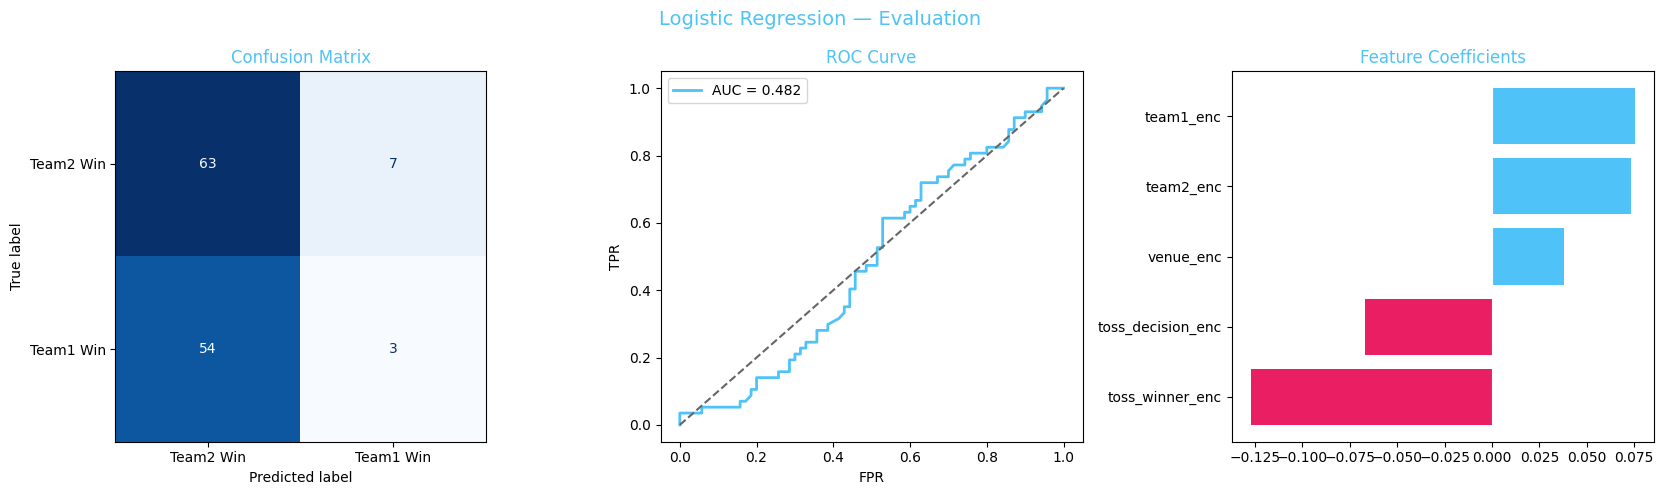

  📊 Plot saved → ./ipl_plots/1_logistic_regression.png
  💾 Model saved → ./ipl_models/logistic_regression.pkl

  MODEL 2 — RANDOM FOREST (Non-linear Match Predictor)

  Accuracy       : 57.48%
  ROC-AUC        : 0.5575
  OOB Score      : 53.56%
  CV Accuracy    : 53.17% ± 3.73%
  Training time  : 5.73s

              precision    recall  f1-score   support

  Team2 Wins       0.61      0.66      0.63        70
  Team1 Wins       0.53      0.47      0.50        57

    accuracy                           0.57       127
   macro avg       0.57      0.57      0.57       127
weighted avg       0.57      0.57      0.57       127



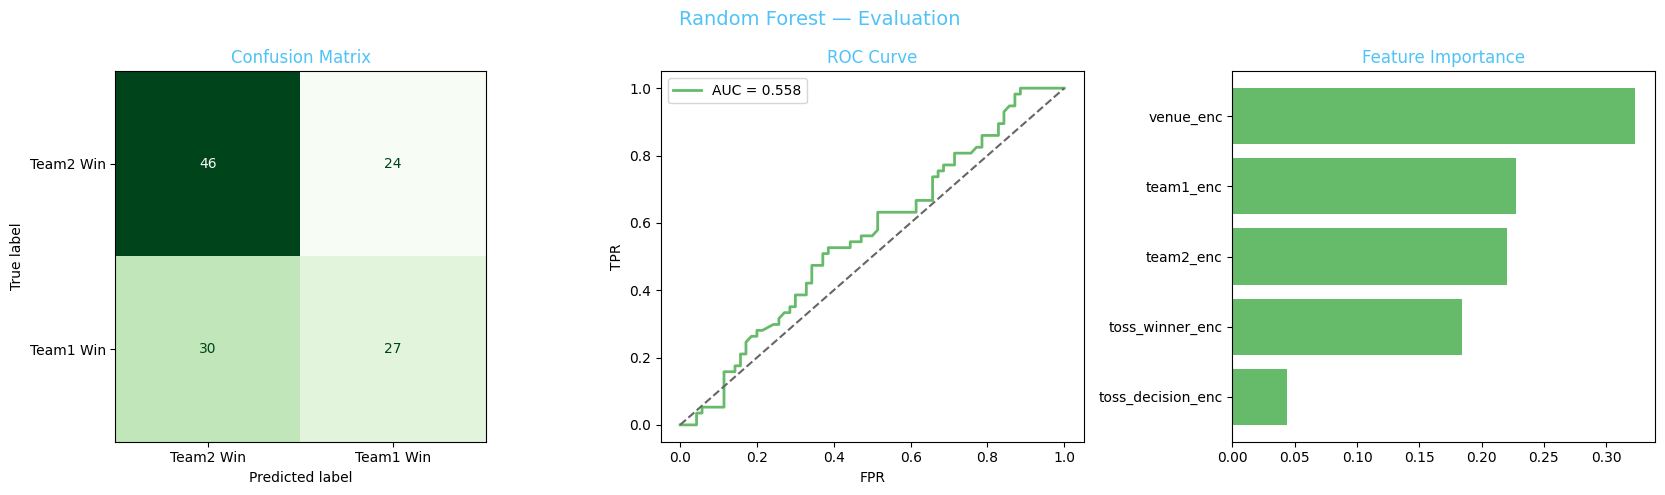

  📊 Plot saved → ./ipl_plots/2_random_forest.png
  💾 Model saved → ./ipl_models/random_forest.pkl

  MODEL 3 — XGBoost (Real-Time Win Probability)

  Accuracy       : 88.47%
  ROC-AUC        : 0.9625
  Training time  : 3.30s

              precision    recall  f1-score   support

Bowling Wins       0.88      0.88      0.88      6831
Batting Wins       0.89      0.89      0.89      7638

    accuracy                           0.88     14469
   macro avg       0.88      0.88      0.88     14469
weighted avg       0.88      0.88      0.88     14469



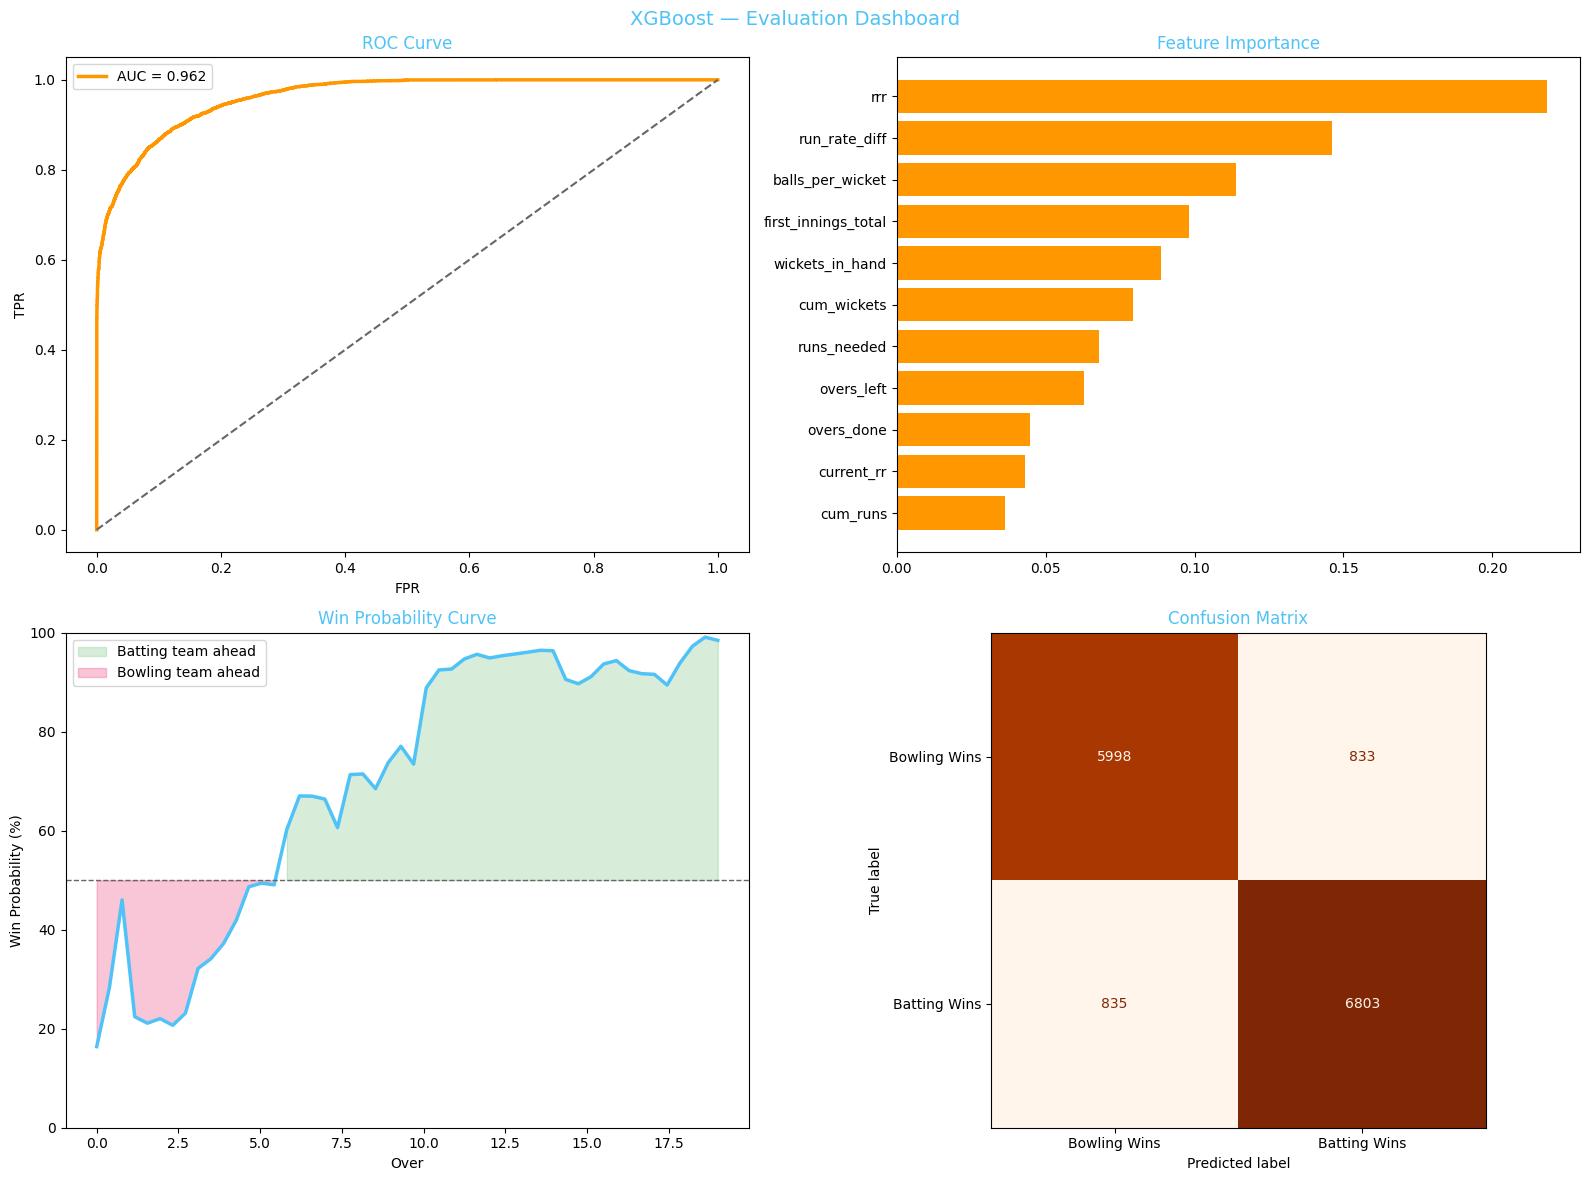

  📊 Plot saved → ./ipl_plots/3_xgboost.png
  💾 Model saved → ./ipl_models/xgboost.pkl

  MODEL 4 — K-MEANS CLUSTERING (Player Role Segmentation)

  Running Elbow method (k = 2 … 10) …

  Inertia        : 623.5
  Training time  : 0.31s

  Cluster Summary:
                avg_runs  strike_rate  avg_fours  avg_sixes  boundary_ratio  consistency
role                                                                                    
⚡ Power Hitter      8.21        96.70       0.69       0.18            0.11         0.94
🎯 Finisher         14.05       125.74       1.30       0.50            0.16         1.60
🔰 All-Rounder       2.95        63.80       0.10       0.03            0.03         0.34
🛡️ Anchor          25.72       128.37       2.54       0.92            0.17         2.94


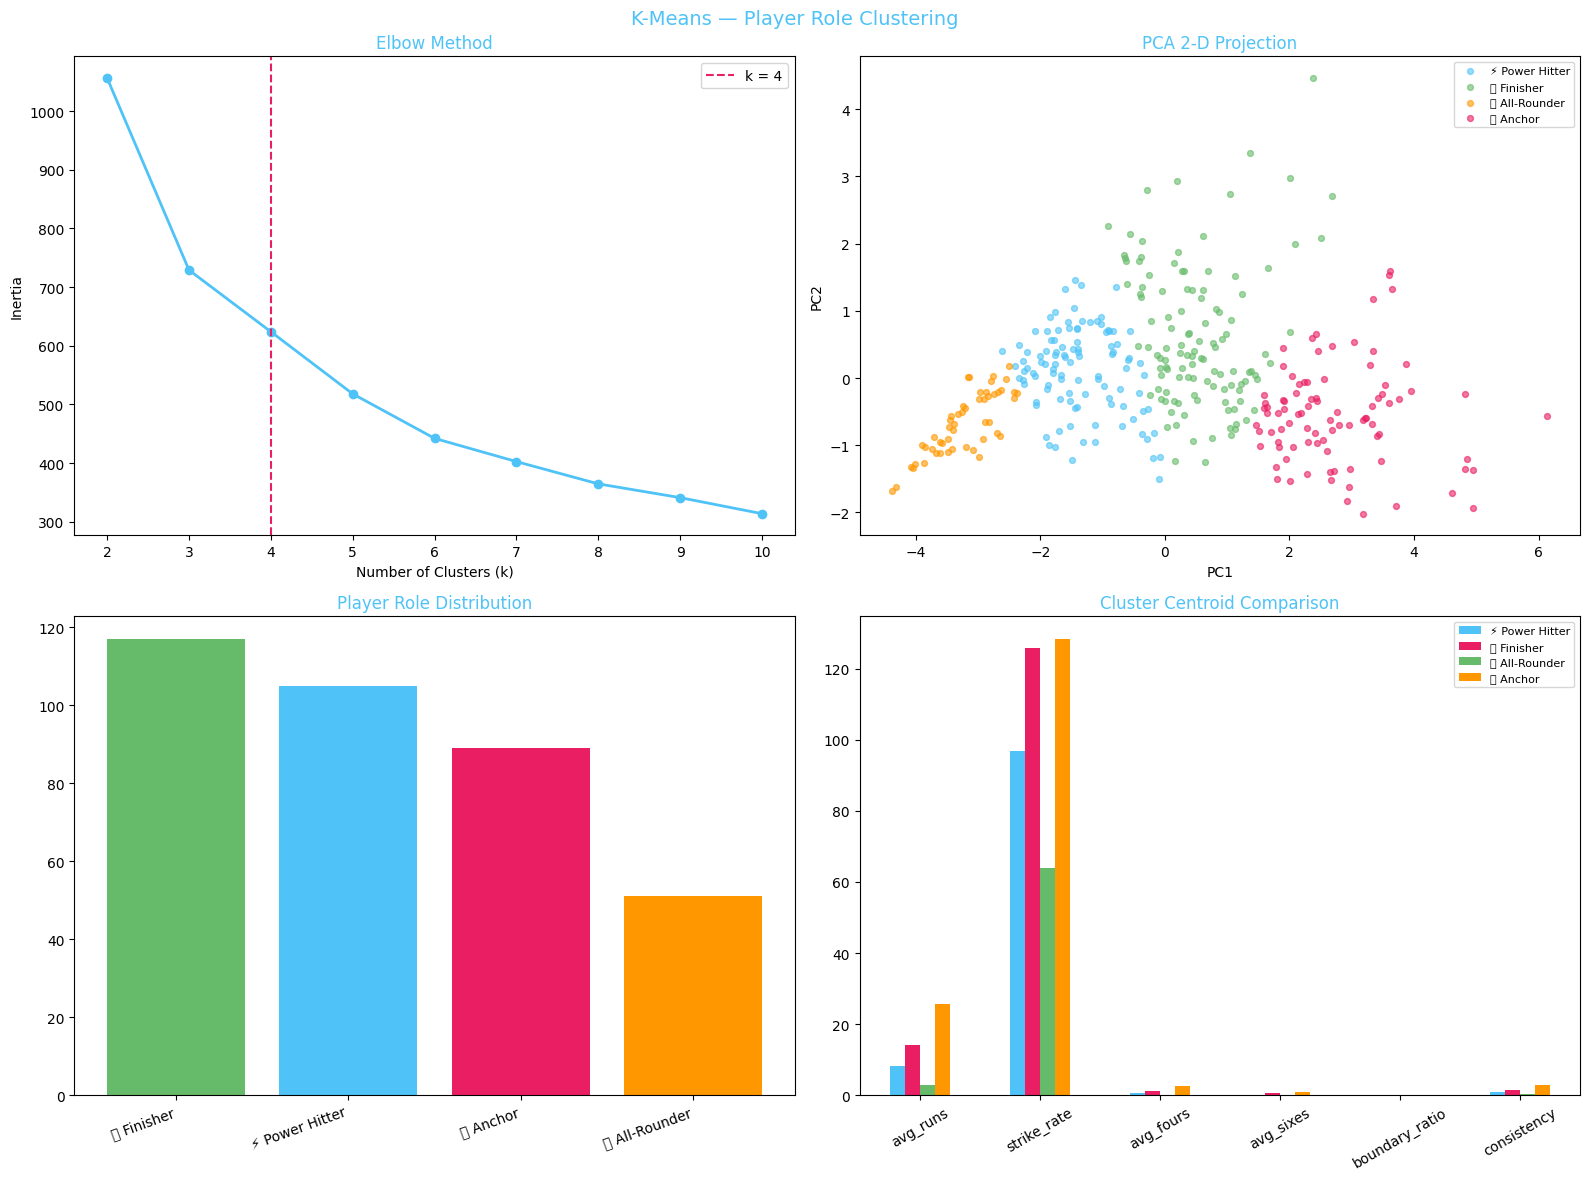

  📊 Plot saved → ./ipl_plots/4_kmeans_clustering.png
  💾 Model saved → ./ipl_models/kmeans.pkl

  FINAL MODEL COMPARISON SUMMARY

  Model                       Accuracy    ROC-AUC  Task
  ------------------------------------------------------------
  Logistic Regression           51.97%     0.4816  Match-level features
  Random Forest                 57.48%     0.5575  Match-level features
  XGBoost / GBM                 88.47%     0.9625  Ball-by-ball features


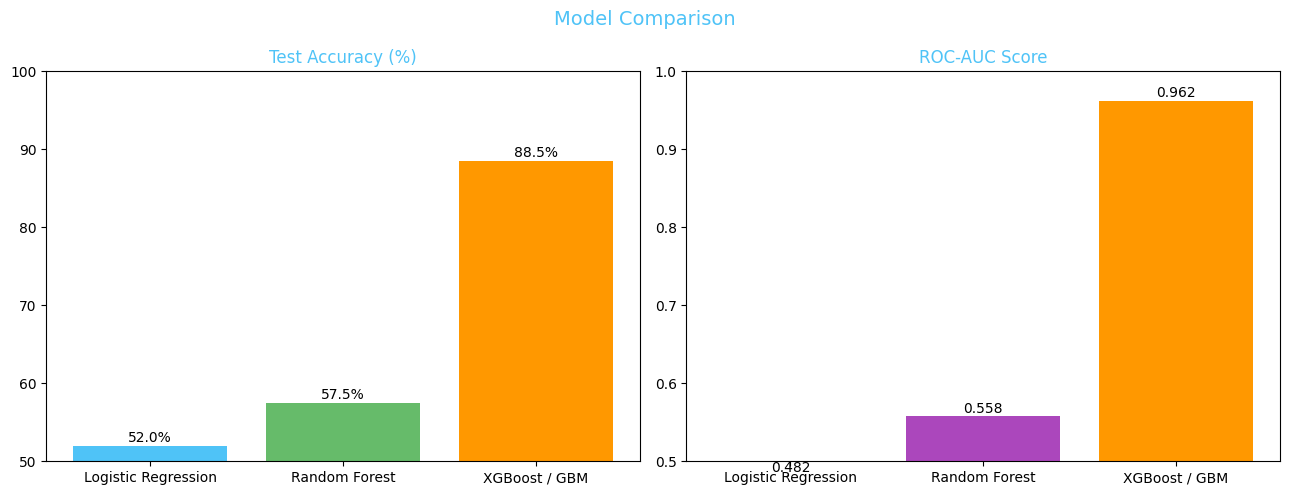


  📊 Comparison plot saved → ./ipl_plots/5_model_comparison.png

  All models saved to → ./ipl_models/
  All plots  saved to → ./ipl_plots/

  ✅ TRAINING COMPLETE

  ⏱  Total pipeline time: 17.9s

-----------------------------------------------------------------
  QUICK INFERENCE DEMO
-----------------------------------------------------------------

  Match Prediction:
    Mumbai Indians: 59.4%
    Chennai Super Kings: 40.6%

  In-Game Win Probability (chase 175, 90/3 after 11 overs):
    Batting team : 83.9000015258789%
    Bowling team : 16.100000381469727%
    Runs needed  : 85 off 54 balls (RRR 9.44)


In [98]:
if __name__ == "__main__":
    total_start = time.time()

    # 1. Load data
    matches_df, deliveries_df = load_data()

    # 2. Feature engineering
    X_match, y_match, match_feats, encoders = build_match_features(matches_df)
    X_bb,    y_bb,    bb_feats             = build_ball_by_ball_features(deliveries_df, matches_df)
    career_df, player_feats                = build_player_features(deliveries_df)

    # 3. Train all four models
    lr_art  = train_logistic_regression(X_match, y_match, match_feats, encoders)
    rf_art  = train_random_forest(X_match, y_match, match_feats, encoders)
    xgb_art = train_xgboost(X_bb, y_bb, bb_feats)
    km_art  = train_kmeans(career_df, player_feats)

    # 4. Summary
    print_summary(lr_art, rf_art, xgb_art)
    print(f"  ⏱  Total pipeline time: {time.time()-total_start:.1f}s")

    # ── Quick inference demo ──
    print("\n" + "-" * 65)
    print("  QUICK INFERENCE DEMO")
    print("-" * 65)

    # Demo 1: Match prediction
    result = predict_match_winner(
        team1="Mumbai Indians", team2="Chennai Super Kings",
        toss_winner="Mumbai Indians", toss_decision="bat",
        venue="Wankhede Stadium", model_name="random_forest")
    print(f"\n  Match Prediction:")
    print(f"    {result['team1']}: {result['team1_win_prob']}%")
    print(f"    {result['team2']}: {result['team2_win_prob']}%")

    # Demo 2: Win probability
    wp = predict_win_probability(
        target=175, runs_scored=90, wickets_lost=3, overs_done=11.0)
    print(f"\n  In-Game Win Probability (chase 175, 90/3 after 11 overs):")
    print(f"    Batting team : {wp['batting_team_win_prob']}%")
    print(f"    Bowling team : {wp['bowling_team_win_prob']}%")
    print(f"    Runs needed  : {wp['runs_needed']} off {int((20-11)*6)} balls (RRR {wp['rrr']})")

App.py

In [144]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os, time
warnings.filterwarnings("ignore")

import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# ─────────────────────────────────────────────────────────────────
#  PAGE CONFIG
# ─────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="IPL Analytics Hub",
    page_icon="🏏",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─────────────────────────────────────────────────────────────────
#  CUSTOM CSS  — Cricket Night Sky aesthetic
# ─────────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Bebas+Neue&family=DM+Sans:wght@300;400;500;600&family=Space+Mono:wght@400;700&display=swap');

:root {
    --gold:    #f5c518;
    --gold2:   #ffd966;
    --teal:    #00d4aa;
    --red:     #ff3a5c;
    --blue:    #1a6bff;
    --bg:      #07090f;
    --surface: #0e1220;
    --card:    #131829;
    --border:  #1e2a42;
    --text:    #d4e4f7;
    --muted:   #5a7090;
}

html, body, [class*="css"] {
    font-family: 'DM Sans', sans-serif;
    background-color: var(--bg);
    color: var(--text);
}

/* ── App background with subtle cricket-pitch grain ── */
.stApp {
    background:
        radial-gradient(ellipse 80% 60% at 50% -10%, rgba(26,107,255,0.12) 0%, transparent 60%),
        radial-gradient(ellipse 50% 40% at 90% 80%,  rgba(0,212,170,0.07) 0%, transparent 55%),
        var(--bg);
}

/* ── Sidebar ── */
section[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #0c1222 0%, #07090f 100%);
    border-right: 1px solid var(--border);
}
section[data-testid="stSidebar"] * { color: var(--text) !important; }
section[data-testid="stSidebar"] .stSelectbox > div,
section[data-testid="stSidebar"] .stMultiSelect > div { border-color: var(--border) !important; }

/* ── Metric cards ── */
[data-testid="stMetric"] {
    background: linear-gradient(135deg, #131829 0%, #0e1624 100%);
    border: 1px solid var(--border);
    border-top: 2px solid var(--gold);
    border-radius: 10px;
    padding: 18px 20px;
}
[data-testid="stMetricValue"] { color: var(--gold) !important; font-family: 'Bebas Neue', sans-serif !important; font-size: 2.2rem !important; letter-spacing: 0.05em; }
[data-testid="stMetricLabel"] { color: var(--muted) !important; font-size: 0.78rem !important; text-transform: uppercase; letter-spacing: 0.1em; }

/* ── Tabs ── */
.stTabs [data-baseweb="tab-list"] {
    background: var(--surface);
    border-radius: 10px;
    padding: 5px;
    gap: 3px;
    border: 1px solid var(--border);
}
.stTabs [data-baseweb="tab"] {
    background: transparent;
    color: var(--muted);
    border-radius: 7px;
    font-family: 'DM Sans', sans-serif;
    font-weight: 600;
    font-size: 0.88rem;
    letter-spacing: 0.02em;
    padding: 8px 14px;
    transition: all 0.2s;
}
.stTabs [aria-selected="true"] {
    background: linear-gradient(135deg, #1a3a80, #0d2255) !important;
    color: var(--gold) !important;
    border: 1px solid rgba(245,197,24,0.3) !important;
}

/* ── Headings ── */
h1 { font-family: 'Bebas Neue', sans-serif !important; color: var(--gold) !important; font-size: 2.8rem !important; letter-spacing: 0.12em; }
h2 { font-family: 'Bebas Neue', sans-serif !important; color: var(--text) !important; font-size: 1.8rem !important; letter-spacing: 0.08em; }
h3 { font-family: 'DM Sans', sans-serif !important; color: var(--teal) !important; font-size: 1.1rem !important; font-weight: 600; }

/* ── Buttons ── */
.stButton > button {
    background: linear-gradient(135deg, #1a6bff 0%, #0d3fa8 100%);
    color: #fff;
    border: none;
    border-radius: 8px;
    font-family: 'Bebas Neue', sans-serif;
    font-size: 1.1rem;
    letter-spacing: 0.1em;
    padding: 12px 24px;
    transition: all 0.2s;
}
.stButton > button:hover { transform: translateY(-2px); box-shadow: 0 8px 24px rgba(26,107,255,0.35); }

/* ── Sliders ── */
.stSlider [data-baseweb="slider"] { color: var(--teal); }

/* ── Info / alert boxes ── */
.info-box {
    background: rgba(26,107,255,0.08);
    border-left: 3px solid var(--blue);
    border-radius: 6px;
    padding: 12px 16px;
    margin: 10px 0 18px;
    color: #a8c4e8;
    font-size: 0.9rem;
}

/* ── Stat pill ── */
.stat-pill {
    display: inline-block;
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 20px;
    padding: 4px 14px;
    font-size: 0.82rem;
    color: var(--muted);
    margin: 3px;
}

/* ── Section divider ── */
.section-line {
    height: 1px;
    background: linear-gradient(90deg, transparent, var(--border), transparent);
    margin: 20px 0;
}

/* ── Win probability card ── */
.wp-card {
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 14px;
    padding: 28px;
    text-align: center;
}
.wp-number {
    font-family: 'Bebas Neue', sans-serif;
    font-size: 4rem;
    letter-spacing: 0.06em;
    line-height: 1;
}

/* ── Model badge ── */
.model-badge {
    background: rgba(0,212,170,0.1);
    border: 1px solid rgba(0,212,170,0.3);
    border-radius: 20px;
    padding: 4px 14px;
    font-size: 0.78rem;
    color: var(--teal);
    font-family: 'Space Mono', monospace;
}

/* ── Table ── */
.dataframe { background: var(--card) !important; color: var(--text) !important; border-radius: 8px; }
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────────
#  CONSTANTS
# ─────────────────────────────────────────────────────────────────
MODEL_DIR  = "./ipl_models"
DATA_ROOTS = ["/content/ipl_data", "./ipl_data", "."]

COLORS = ["#f5c518","#00d4aa","#ff3a5c","#1a6bff","#a855f7","#fb923c","#34d399","#f472b6"]

PLOTLY_DARK = dict(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(14,18,32,0.85)",
    font=dict(color="#d4e4f7", family="DM Sans"),
    xaxis=dict(gridcolor="#1e2a42", zerolinecolor="#1e2a42"),
    yaxis=dict(gridcolor="#1e2a42", zerolinecolor="#1e2a42"),
)


# ─────────────────────────────────────────────────────────────────
#  MODEL LOADING  (from pre-saved pkl files)
# ─────────────────────────────────────────────────────────────────
@st.cache_resource(show_spinner=False)
def load_pretrained_models():
    """Load models saved by ipl_model_training_1_.py."""
    loaded = {}
    model_names = {
        "logistic_regression": "Logistic Regression",
        "random_forest":       "Random Forest",
        "xgboost":             "XGBoost / GBM",
        "kmeans":              "K-Means Clustering",
    }
    for key, label in model_names.items():
        path = os.path.join(MODEL_DIR, f"{key}.pkl")
        if os.path.exists(path):
            try:
                loaded[key] = joblib.load(path)
                loaded[key]["__label__"] = label
            except Exception as e:
                st.warning(f"Could not load {label}: {e}")
    return loaded


# ─────────────────────────────────────────────────────────────────
#  DATA LOADING
# ─────────────────────────────────────────────────────────────────
@st.cache_data(show_spinner=False)
def find_and_load_csvs():
    matches_df = deliveries_df = None
    match_names    = ["matches.csv", "IPL Matches 2008-2020.csv", "ipl_matches.csv"]
    delivery_names = ["deliveries.csv", "IPL Ball-by-Ball 2008-2020.csv", "ipl_deliveries.csv"]
    for root in DATA_ROOTS:
        for fn in match_names:
            p = os.path.join(root, fn)
            if os.path.exists(p):
                matches_df = pd.read_csv(p); break
        for fn in delivery_names:
            p = os.path.join(root, fn)
            if os.path.exists(p):
                deliveries_df = pd.read_csv(p); break
        if matches_df is not None and deliveries_df is not None:
            break
    return matches_df, deliveries_df


@st.cache_data(show_spinner=False)
def generate_synthetic_data():
    rng = np.random.default_rng(42)
    teams = [
        "Mumbai Indians", "Chennai Super Kings", "Royal Challengers Bangalore",
        "Kolkata Knight Riders", "Sunrisers Hyderabad", "Delhi Capitals",
        "Punjab Kings", "Rajasthan Royals", "Gujarat Titans", "Lucknow Super Giants",
    ]
    venues = [
        "Wankhede Stadium", "M Chinnaswamy Stadium", "Eden Gardens",
        "MA Chidambaram Stadium", "Arun Jaitley Stadium",
        "Rajiv Gandhi Intl Stadium", "PCA IS Bindra Stadium",
        "Sawai Mansingh Stadium", "Narendra Modi Stadium", "DY Patil Stadium",
    ]
    seasons     = list(range(2008, 2025))
    player_pool = [f"Player_{i}" for i in range(1, 201)]
    n_matches   = 900
    m_rows = []
    for mid in range(1, n_matches + 1):
        t1, t2 = rng.choice(teams, size=2, replace=False)
        tw = rng.choice([t1, t2])
        td = rng.choice(["bat", "field"])
        p  = 0.55 if (tw == t1 and td == "bat") else 0.48
        w  = t1 if rng.random() < p else t2
        m_rows.append({"id": mid, "season": rng.choice(seasons),
                        "city": rng.choice(venues), "venue": rng.choice(venues),
                        "team1": t1, "team2": t2, "toss_winner": tw,
                        "toss_decision": td, "winner": w,
                        "player_of_match": rng.choice(player_pool),
                        "result": "normal", "dl_applied": 0})
    matches_df = pd.DataFrame(m_rows)

    rows = []
    run_probs = [0.30, 0.25, 0.15, 0.10, 0.08, 0.05, 0.07]
    for _, match in matches_df.iterrows():
        bat1 = match["team1"] if match["toss_decision"] == "bat" else match["team2"]
        bat2 = match["team2"] if bat1 == match["team1"] else match["team1"]
        for innings, bt in enumerate([bat1, bat2], 1):
            bwlt = bat2 if innings == 1 else bat1
            batsmen = rng.choice(player_pool, size=11, replace=False)
            bowlers = rng.choice(player_pool, size=7,  replace=False)
            wk = 0
            for b in range(120):
                if wk >= 10: break
                ov = b // 6; bl = b % 6 + 1
                btr = batsmen[min(wk, 10)]; bwl = bowlers[ov % len(bowlers)]
                br = int(rng.choice([0,1,2,3,4,5,6], p=run_probs))
                wide = noball = er = 0
                if rng.random() < 0.03: wide = 1; br = 0; er = 1
                elif rng.random() < 0.02: noball = 1; er = 1
                iw = 0; pd_val = np.nan
                if rng.random() < 0.06 and not wide:
                    iw = 1; pd_val = btr; wk += 1
                rows.append({"match_id": match["id"], "inning": innings,
                              "batting_team": bt, "bowling_team": bwlt,
                              "over": ov, "ball": bl, "batter": btr, "bowler": bwl,
                              "non_striker": batsmen[min(wk+1,10)],
                              "batsman_runs": br, "extra_runs": er,
                              "total_runs": br+er,
                              "extras_type": "wides" if wide else ("noballs" if noball else np.nan),
                              "is_wicket": iw, "player_dismissed": pd_val,
                              "dismissal_kind": "caught" if iw else np.nan})
    return matches_df, pd.DataFrame(rows)


@st.cache_data(show_spinner=False)
def load_all_data():
    m, d = find_and_load_csvs()
    if m is None or d is None:
        m, d = generate_synthetic_data()
    m.columns = [c.lower().replace(" ","_") for c in m.columns]
    d.columns = [c.lower().replace(" ","_") for c in d.columns]
    if "id" not in m.columns and "match_id" in m.columns:
        m.rename(columns={"match_id":"id"}, inplace=True)
    if "match_id" not in d.columns and "id" in d.columns:
        d.rename(columns={"id":"match_id"}, inplace=True)
    m.dropna(subset=["winner"], inplace=True)
    return m, d


# ─────────────────────────────────────────────────────────────────
#  FALLBACK INLINE TRAINING  (if pkl files missing)
# ─────────────────────────────────────────────────────────────────
@st.cache_resource(show_spinner=False)
def train_fallback_models(matches_df, deliveries_df):
    """Train models on-the-fly if pkl files are absent."""
    models = {}

    # Match-level features
    df = matches_df.copy().dropna(subset=["winner"])
    encoders = {}
    for col in ["team1","team2","toss_winner","toss_decision","venue"]:
        if col in df.columns:
            le = LabelEncoder()
            df[col+"_enc"] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
    df["team1_win"] = (df["winner"] == df["team1"]).astype(int)
    feat_cols = [c+"_enc" for c in ["team1","team2","toss_winner","toss_decision","venue"] if c+"_enc" in df.columns]
    X_m = df[feat_cols].fillna(0); y_m = df["team1_win"]
    Xtr, Xte, ytr, yte = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

    lr = LogisticRegression(max_iter=500, random_state=42)
    lr.fit(Xtr, ytr)
    models["logistic_regression"] = {"model": lr, "accuracy": accuracy_score(yte, lr.predict(Xte)),
                                      "features": feat_cols, "encoders": encoders, "__label__": "Logistic Regression"}

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)
    models["random_forest"] = {"model": rf, "accuracy": accuracy_score(yte, rf.predict(Xte)),
                                "features": feat_cols, "encoders": encoders, "__label__": "Random Forest"}

    # Ball-by-ball
    inn1 = deliveries_df[deliveries_df["inning"]==1].groupby("match_id")["total_runs"].sum().reset_index()
    inn1.rename(columns={"total_runs":"first_innings_total"}, inplace=True)
    inn2 = deliveries_df[deliveries_df["inning"]==2].copy().sort_values(["match_id","over","ball"])
    inn2["cum_runs"]    = inn2.groupby("match_id")["total_runs"].cumsum()
    inn2["cum_wickets"] = inn2.groupby("match_id")["is_wicket"].cumsum()
    inn2["balls_done"]  = inn2.groupby("match_id").cumcount() + 1
    inn2["overs_done"]  = (inn2["balls_done"]-1)//6
    inn2["balls_left"]  = (120 - inn2["balls_done"]).clip(lower=0)
    inn2["overs_left"]  = inn2["balls_left"] / 6
    inn2 = inn2.merge(inn1, on="match_id", how="left")
    inn2["runs_needed"]     = (inn2["first_innings_total"]+1 - inn2["cum_runs"]).clip(lower=0)
    inn2["rrr"]             = np.where(inn2["balls_left"]>0, inn2["runs_needed"]/(inn2["balls_left"]/6), 0)
    inn2["current_rr"]      = np.where(inn2["balls_done"]>0, inn2["cum_runs"]/(inn2["balls_done"]/6), 0)
    inn2["wickets_in_hand"] = (10 - inn2["cum_wickets"]).clip(lower=0)
    inn2["run_rate_diff"]   = inn2["current_rr"] - inn2["rrr"]
    inn2["balls_per_wicket"]= np.where(inn2["cum_wickets"]>0, inn2["balls_done"]/inn2["cum_wickets"], 120)
    outcome = matches_df[["id","winner"]].rename(columns={"id":"match_id"})
    bt = inn2[["match_id","batting_team"]].drop_duplicates("match_id")
    outcome = outcome.merge(bt, on="match_id", how="left")
    outcome["batting_wins"] = (outcome["winner"]==outcome["batting_team"]).astype(int)
    inn2 = inn2.merge(outcome[["match_id","batting_wins"]], on="match_id", how="left")
    inn2.dropna(subset=["batting_wins","first_innings_total","rrr"], inplace=True)
    BB_FEATS = ["first_innings_total","cum_runs","cum_wickets","overs_done","overs_left",
                "runs_needed","rrr","current_rr","wickets_in_hand","run_rate_diff","balls_per_wicket"]
    X_bb = inn2[BB_FEATS].fillna(0); y_bb = inn2["batting_wins"].astype(int)
    Xtr2, Xte2, ytr2, yte2 = train_test_split(X_bb, y_bb, test_size=0.2, random_state=42)
    sc2 = StandardScaler(); Xtr2s = sc2.fit_transform(Xtr2); Xte2s = sc2.transform(Xte2)
    if XGBOOST_AVAILABLE:
        xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                             use_label_encoder=False, eval_metric="logloss",
                             random_state=42, verbosity=0)
        xgb.fit(Xtr2s, ytr2)
        xgb_model = xgb
    else:
        xgb_model = GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                                learning_rate=0.1, random_state=42)
        xgb_model.fit(Xtr2s, ytr2)
    models["xgboost"] = {"model": xgb_model, "scaler": sc2,
                          "accuracy": accuracy_score(yte2, xgb_model.predict(Xte2s)),
                          "features": BB_FEATS, "__label__": "XGBoost / GBM"}

    # K-Means
    bat = deliveries_df[deliveries_df["inning"].isin([1,2])].copy()
    per = bat.groupby(["match_id","batter"]).agg(
        runs=("batsman_runs","sum"), balls=("ball","count"),
        fours=("batsman_runs", lambda x: (x==4).sum()),
        sixes=("batsman_runs", lambda x: (x==6).sum())).reset_index()
    career = per.groupby("batter").agg(
        avg_runs=("runs","mean"), avg_sr=("runs", lambda x: x.mean()),
        avg_fours=("fours","mean"), avg_sixes=("sixes","mean"),
        innings=("match_id","nunique")).reset_index()
    career["strike_rate"] = career["avg_runs"] / np.maximum(per.groupby("batter")["balls"].mean().reindex(career.index).values, 1) * 100
    career = career[career["innings"]>=3].reset_index(drop=True)
    KM_FEATS = ["avg_runs","avg_fours","avg_sixes","innings"]
    X_km = career[KM_FEATS].fillna(0)
    sc_km = StandardScaler(); X_kms = sc_km.fit_transform(X_km)
    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    career["cluster"] = km.fit_predict(X_kms)
    cluster_labels = {0:"⚡ Power Hitter", 1:"🛡️ Anchor", 2:"🎯 Finisher", 3:"🔰 All-Rounder"}
    career["role"] = career["cluster"].map(cluster_labels)
    models["kmeans"] = {"model": km, "scaler": sc_km, "player_clusters": career,
                         "features": KM_FEATS, "cluster_labels": cluster_labels, "__label__": "K-Means"}

    return models


# ─────────────────────────────────────────────────────────────────
#  PLAYER STATS
# ─────────────────────────────────────────────────────────────────
@st.cache_data(show_spinner=False)
def build_player_stats(deliveries_df, matches_df):
    if "is_wicket" not in deliveries_df.columns:
        deliveries_df["is_wicket"] = deliveries_df["player_dismissed"].notna().astype(int)
    bat = deliveries_df[deliveries_df["inning"].isin([1,2])].copy()
    bat_stats = bat.groupby(["match_id","batsman"]).agg(
        runs=("batsman_runs","sum"), balls=("ball","count"),
        fours=("batsman_runs", lambda x: (x==4).sum()),
        sixes=("batsman_runs", lambda x: (x==6).sum())).reset_index()
    season_map = matches_df[["id","season"]].rename(columns={"id":"match_id"})
    bat_stats  = bat_stats.merge(season_map, on="match_id", how="left")
    bat_agg = bat_stats.groupby(["batsman","season"]).agg(
        total_runs=("runs","sum"), total_balls=("balls","sum"),
        innings=("match_id","nunique"), fours=("fours","sum"), sixes=("sixes","sum")).reset_index()
    bat_agg["strike_rate"]  = np.where(bat_agg["total_balls"]>0, bat_agg["total_runs"]/bat_agg["total_balls"]*100, 0)
    bat_agg["batting_avg"]  = np.where(bat_agg["innings"]>0, bat_agg["total_runs"]/bat_agg["innings"], 0)

    bowl = bat.copy()
    bowl_stats = bowl.groupby(["match_id","bowler"]).agg(
        runs_conceded=("total_runs","sum"), balls=("ball","count"),
        wickets=("is_wicket","sum")).reset_index()
    bowl_stats = bowl_stats.merge(season_map, on="match_id", how="left")
    bowl_agg = bowl_stats.groupby(["bowler","season"]).agg(
        total_runs=("runs_conceded","sum"), total_balls=("balls","sum"),
        total_wickets=("wickets","sum"), matches=("match_id","nunique")).reset_index()
    bowl_agg["economy"] = np.where(bowl_agg["total_balls"]>0, bowl_agg["total_runs"]/(bowl_agg["total_balls"]/6), 0)

    return bat_agg, bowl_agg


# ─────────────────────────────────────────────────────────────────
#  SIDEBAR
# ─────────────────────────────────────────────────────────────────
def render_sidebar(matches_df, models, using_pretrained):
    with st.sidebar:
        st.markdown("""
        <div style='text-align:center; padding:16px 0 24px;'>
            <div style='font-size:3.2rem; line-height:1;'>🏏</div>
            <div style='font-family:"Bebas Neue"; font-size:1.7rem; color:#f5c518;
                        letter-spacing:0.15em; margin-top:6px;'>IPL ANALYTICS</div>
            <div style='font-size:0.72rem; color:#5a7090; margin-top:2px;'>
                2008 – 2024 Intelligence Hub
            </div>
        </div>
        """, unsafe_allow_html=True)

        # Model status banner
        if using_pretrained:
            st.markdown("""<div style='background:rgba(0,212,170,0.1);border:1px solid rgba(0,212,170,0.3);
                border-radius:8px;padding:10px 14px;margin-bottom:16px;font-size:0.82rem;color:#00d4aa;'>
                ✅ <b>Pre-trained models loaded</b><br>
                <span style='color:#5a7090;font-size:0.75rem;'>From ipl_model_training_1_.py</span>
            </div>""", unsafe_allow_html=True)
        else:
            st.markdown("""<div style='background:rgba(245,197,24,0.08);border:1px solid rgba(245,197,24,0.25);
                border-radius:8px;padding:10px 14px;margin-bottom:16px;font-size:0.82rem;color:#f5c518;'>
                ⚡ <b>Models trained on-the-fly</b><br>
                <span style='color:#5a7090;font-size:0.75rem;'>Run training script for faster load</span>
            </div>""", unsafe_allow_html=True)

        st.markdown("### 📅 Filters")
        seasons = sorted(matches_df["season"].dropna().unique())
        sel_seasons = st.multiselect("Seasons", seasons, default=list(seasons)[-5:])

        teams = sorted(set(matches_df["team1"].dropna().tolist() + matches_df["team2"].dropna().tolist()))
        sel_teams = st.multiselect("Teams", teams, default=[])

        st.markdown("<div class='section-line'></div>", unsafe_allow_html=True)
        st.markdown("### 📊 Dataset")
        c1, c2 = st.columns(2)
        c1.metric("Matches", f"{len(matches_df):,}")
        c2.metric("Seasons", len(seasons))
        st.metric("Teams", len(teams))

        st.markdown("<div class='section-line'></div>", unsafe_allow_html=True)
        st.markdown("### 🤖 Models")
        model_map = {
            "logistic_regression": ("📉", "LR"),
            "random_forest":       ("🌳", "RF"),
            "xgboost":             ("⚡", "XGB"),
            "kmeans":              ("🔬", "KM"),
        }
        for key, (icon, short) in model_map.items():
            if key in models:
                acc = models[key].get("accuracy", None)
                acc_str = f"{acc*100:.1f}%" if acc else "—"
                st.markdown(f"<span class='stat-pill'>{icon} {short}: {acc_str}</span>", unsafe_allow_html=True)

    return sel_seasons, sel_teams


# ─────────────────────────────────────────────────────────────────
#  TAB 1 — OVERVIEW
# ─────────────────────────────────────────────────────────────────
def tab_overview(matches_df, sel_seasons, sel_teams):
    st.markdown("## 📊 Tournament Overview")
    df = matches_df.copy()
    if sel_seasons: df = df[df["season"].isin(sel_seasons)]
    if sel_teams:   df = df[df["team1"].isin(sel_teams) | df["team2"].isin(sel_teams)]

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Matches", f"{len(df):,}")
    toss_adv = (df["toss_winner"]==df["winner"]).mean()*100 if "toss_winner" in df.columns else 0
    c2.metric("Toss → Win %", f"{toss_adv:.1f}%")
    c3.metric("Venues", df["venue"].nunique() if "venue" in df.columns else "—")
    c4.metric("Unique PoM", df["player_of_match"].nunique() if "player_of_match" in df.columns else "—")

    st.markdown("<div class='section-line'></div>", unsafe_allow_html=True)
    col_a, col_b = st.columns(2)

    with col_a:
        wins = df["winner"].value_counts().head(10).reset_index()
        wins.columns = ["team","wins"]
        fig = px.bar(wins, x="wins", y="team", orientation="h",
                     color="wins", color_continuous_scale=[[0,"#1e2a42"],[1,"#f5c518"]],
                     title="🏆 Most Wins by Team", labels={"wins":"Wins","team":""})
        fig.update_layout(**PLOTLY_DARK, height=380, coloraxis_showscale=False)
        st.plotly_chart(fig, use_container_width=True)

    with col_b:
        ms = df.groupby("season").size().reset_index(name="matches")
        fig = px.area(ms, x="season", y="matches", markers=True,
                      title="📅 Matches per Season",
                      color_discrete_sequence=["#00d4aa"])
        fig.update_traces(fillcolor="rgba(0,212,170,0.12)", line_color="#00d4aa")
        fig.update_layout(**PLOTLY_DARK, height=380)
        st.plotly_chart(fig, use_container_width=True)

    col_c, col_d = st.columns(2)

    with col_c:
        if "toss_decision" in df.columns:
            td = df["toss_decision"].value_counts().reset_index()
            td.columns = ["decision","count"]
            fig = px.pie(td, names="decision", values="count",
                         title="🎲 Toss Decision Split",
                         color_discrete_sequence=["#1a6bff","#ff3a5c"],
                         hole=0.55)
            fig.update_layout(**PLOTLY_DARK, height=340)
            st.plotly_chart(fig, use_container_width=True)

    with col_d:
        if "venue" in df.columns:
            vc = df["venue"].value_counts().head(8).reset_index()
            vc.columns = ["venue","matches"]
            fig = px.bar(vc, x="venue", y="matches",
                         color="matches", color_continuous_scale=[[0,"#0e1220"],[1,"#00d4aa"]],
                         title="🏟️ Top Venues by Matches",
                         labels={"venue":"","matches":"Matches"})
            fig.update_layout(**PLOTLY_DARK, height=340, coloraxis_showscale=False, xaxis_tickangle=-35)
            st.plotly_chart(fig, use_container_width=True)

    # Winner trend
    st.markdown("#### 🏅 IPL Champions Season-wise")
    if "season" in df.columns and "winner" in df.columns:
        champs = df.sort_values("season").groupby("season")["winner"].last().reset_index()
        champs.columns = ["Season","Champion"]
        fig = px.scatter(champs, x="Season", y="Champion",
                         color="Champion", size=[20]*len(champs),
                         color_discrete_sequence=COLORS,
                         title="Season Champions")
        fig.update_layout(**PLOTLY_DARK, height=340, showlegend=False)
        st.plotly_chart(fig, use_container_width=True)


# ─────────────────────────────────────────────────────────────────
#  TAB 2 — MATCH PREDICTOR  (uses LR / RF from training script)
# ─────────────────────────────────────────────────────────────────
def tab_match_predictor(models, matches_df):
    st.markdown("## 🏟️ Pre-Match Win Predictor")
    st.markdown("<div class='info-box'>Select two teams, toss details and venue. The model uses <b>Logistic Regression</b> or <b>Random Forest</b> (trained on match-level features) to estimate win probability before a ball is bowled.</div>", unsafe_allow_html=True)

    teams = sorted(set(matches_df["team1"].dropna().tolist() + matches_df["team2"].dropna().tolist()))
    venues = sorted(matches_df["venue"].dropna().unique()) if "venue" in matches_df.columns else ["Unknown"]

    col1, col2, col3 = st.columns(3)
    with col1:
        t1 = st.selectbox("🏏 Team 1", teams, index=0)
        t2_opts = [t for t in teams if t != t1]
        t2 = st.selectbox("🏏 Team 2", t2_opts, index=0)
    with col2:
        toss_winner   = st.selectbox("🎲 Toss Won By", [t1, t2])
        toss_decision = st.selectbox("🎯 Toss Decision", ["bat", "field"])
    with col3:
        venue     = st.selectbox("🏟️ Venue", venues)
        model_key = st.selectbox("🤖 Model", ["random_forest","logistic_regression"],
                                 format_func=lambda x: x.replace("_"," ").title())

    predict_btn = st.button("⚡ PREDICT MATCH OUTCOME", use_container_width=True)

    if predict_btn:
        if model_key in models:
            art = models[model_key]
            row = {}
            val_map = {"team1":t1,"team2":t2,"toss_winner":toss_winner,
                       "toss_decision":toss_decision,"venue":venue}
            for col in art["features"]:
                base = col.replace("_enc","")
                raw  = val_map.get(base, "Unknown")
                try:
                    row[col] = art["encoders"][base].transform([raw])[0]
                except Exception:
                    row[col] = 0
            X = pd.DataFrame([row])[art["features"]]
            if "scaler" in art:
                X = art["scaler"].transform(X)
            prob_t1 = art["model"].predict_proba(X)[0][1] * 100
            prob_t2 = 100 - prob_t1
        else:
            prob_t1 = 50.0; prob_t2 = 50.0

        c1, c2 = st.columns(2)
        col1_color = "#00d4aa" if prob_t1 >= 50 else "#ff3a5c"
        col2_color = "#00d4aa" if prob_t2 >= 50 else "#ff3a5c"
        c1.markdown(f"""
            <div class='wp-card'>
                <div style='font-size:0.85rem;color:#5a7090;text-transform:uppercase;letter-spacing:0.1em;'>{t1}</div>
                <div class='wp-number' style='color:{col1_color};'>{prob_t1:.1f}%</div>
                <div style='font-size:0.8rem;color:#5a7090;'>Estimated Win Probability</div>
                {'<div style="margin-top:8px;font-size:1.2rem;">🏆 FAVOURITE</div>' if prob_t1>=50 else ''}
            </div>""", unsafe_allow_html=True)
        c2.markdown(f"""
            <div class='wp-card'>
                <div style='font-size:0.85rem;color:#5a7090;text-transform:uppercase;letter-spacing:0.1em;'>{t2}</div>
                <div class='wp-number' style='color:{col2_color};'>{prob_t2:.1f}%</div>
                <div style='font-size:0.8rem;color:#5a7090;'>Estimated Win Probability</div>
                {'<div style="margin-top:8px;font-size:1.2rem;">🏆 FAVOURITE</div>' if prob_t2>=50 else ''}
            </div>""", unsafe_allow_html=True)

        # Bar comparison
        fig = go.Figure(go.Bar(
            x=[t1, t2], y=[prob_t1, prob_t2],
            marker_color=[col1_color, col2_color],
            text=[f"{prob_t1:.1f}%", f"{prob_t2:.1f}%"], textposition="outside",
        ))
        fig.update_layout(**PLOTLY_DARK, height=280, title="Win Probability Comparison",
                           yaxis_range=[0,110], showlegend=False)
        st.plotly_chart(fig, use_container_width=True)
        if model_key in models:
            acc = models[model_key].get("accuracy", None)
            if acc:
                st.markdown(f"<span class='model-badge'>Model accuracy: {acc*100:.1f}%</span>", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────────
#  TAB 3 — LIVE WIN PROBABILITY  (XGBoost)
# ─────────────────────────────────────────────────────────────────
def tab_win_probability(models):
    st.markdown("## 🎯 Live Win Probability Simulator")
    st.markdown("<div class='info-box'>Input the <b>current match state</b> during the second innings. XGBoost (trained on ball-by-ball data) estimates win probability in real time.</div>", unsafe_allow_html=True)

    col1, col2 = st.columns(2)
    with col1:
        target       = st.number_input("🎯 Target (1st innings + 1)", 80, 350, 175)
        runs_scored  = st.number_input("🏃 Runs scored so far",   0, int(target)-1, 85)
        wickets_lost = st.slider("❌ Wickets lost", 0, 9, 3)
    with col2:
        overs_done = st.slider("🕐 Overs completed", 0.0, 19.5, 10.0, step=0.1)
        balls_done     = int(overs_done * 6)
        balls_left     = max(0, 120 - balls_done)
        runs_needed    = max(0, target - runs_scored)
        rrr            = runs_needed / (balls_left/6) if balls_left > 0 else 99
        curr_rr        = runs_scored / (balls_done/6) if balls_done > 0 else 0
        wih            = 10 - wickets_lost

        # Derived stats card
        rr_delta = curr_rr - rrr
        rr_color = "#00d4aa" if rr_delta >= 0 else "#ff3a5c"
        st.markdown(f"""
        <div style='background:var(--card);border:1px solid var(--border);border-radius:12px;padding:18px;margin-top:8px;'>
            <div style='font-family:"Bebas Neue";font-size:1.1rem;color:#5a7090;letter-spacing:0.1em;margin-bottom:10px;'>MATCH STATE</div>
            <div style='display:grid;grid-template-columns:1fr 1fr;gap:8px;font-size:0.9rem;'>
                <div>Runs Needed <b style='color:#f5c518;'>{runs_needed}</b></div>
                <div>Balls Left <b style='color:#d4e4f7;'>{balls_left}</b></div>
                <div>Req RR <b style='color:#ff3a5c;'>{rrr:.2f}</b></div>
                <div>Curr RR <b style='color:#00d4aa;'>{curr_rr:.2f}</b></div>
                <div>RR Diff <b style='color:{rr_color};'>{rr_delta:+.2f}</b></div>
                <div>Wickets Left <b style='color:#d4e4f7;'>{wih}</b></div>
            </div>
        </div>""", unsafe_allow_html=True)

    btn = st.button("⚡ CALCULATE WIN PROBABILITY", use_container_width=True)

    if btn:
        if "xgboost" in models:
            art = models["xgboost"]
            features = art["features"]
            inp_dict = {
                "first_innings_total": target-1, "cum_runs": runs_scored,
                "cum_wickets": wickets_lost, "overs_done": overs_done,
                "overs_left":  balls_left/6, "overs_remaining": balls_left/6,
                "runs_needed": runs_needed, "rrr": rrr, "current_rr": curr_rr,
                "wickets_in_hand": wih, "run_rate_diff": curr_rr-rrr,
                "balls_per_wicket": balls_done/wickets_lost if wickets_lost>0 else 120,
                "balls_remaining": balls_left,
            }
            inp = pd.DataFrame([{f: inp_dict.get(f, 0) for f in features}])[features]
            inp_s = art["scaler"].transform(inp)
            prob  = art["model"].predict_proba(inp_s)[0][1] * 100
        else:
            rr_ratio = curr_rr / max(rrr, 0.1)
            prob = np.clip((rr_ratio*0.6 + (wih/10)*0.4)*100, 5, 95)

        # Gauge
        fig = go.Figure(go.Indicator(
            mode="gauge+number+delta",
            value=prob,
            delta={"reference": 50, "suffix":"%", "font":{"size":14}},
            number={"suffix":"%","font":{"size":52,"color":"#f5c518","family":"Bebas Neue"}},
            gauge={
                "axis": {"range":[0,100], "tickcolor":"#5a7090"},
                "bar":  {"color":"#1a6bff","thickness":0.3},
                "bgcolor": "#0e1220",
                "bordercolor":"#1e2a42",
                "steps": [
                    {"range":[0,30],"color":"#2d0a14"},
                    {"range":[30,50],"color":"#1a0e00"},
                    {"range":[50,70],"color":"#0a1a10"},
                    {"range":[70,100],"color":"#0a1a10"},
                ],
                "threshold":{"line":{"color":"#f5c518","width":3},"thickness":0.85,"value":prob},
            },
            title={"text":"Batting Team Win Probability","font":{"size":16,"color":"#5a7090","family":"DM Sans"}},
        ))
        fig.update_layout(**PLOTLY_DARK, height=400)
        st.plotly_chart(fig, use_container_width=True)

        bat_col = "#00d4aa" if prob>=50 else "#ff3a5c"
        bowl_col = "#00d4aa" if (100-prob)>=50 else "#ff3a5c"
        c1, c2 = st.columns(2)
        c1.markdown(f"""<div class='wp-card'>
            <div style='color:#5a7090;font-size:0.75rem;text-transform:uppercase;letter-spacing:0.1em;'>Batting Team</div>
            <div class='wp-number' style='color:{bat_col};'>{prob:.1f}%</div>
        </div>""", unsafe_allow_html=True)
        c2.markdown(f"""<div class='wp-card'>
            <div style='color:#5a7090;font-size:0.75rem;text-transform:uppercase;letter-spacing:0.1em;'>Bowling Team</div>
            <div class='wp-number' style='color:{bowl_col};'>{100-prob:.1f}%</div>
        </div>""", unsafe_allow_html=True)

        # Win probability curve across overs
        overs_range = np.linspace(0, overs_done, 40)
        demo_probs  = []
        for ov in overs_range:
            bd = int(ov*6); bl = max(0,120-bd)
            rs = runs_scored*(ov/max(overs_done,0.1))
            rn = max(0, target - rs)
            r  = rn/(bl/6) if bl>0 else 99
            cr = rs/(bd/6) if bd>0 else 0
            if "xgboost" in models:
                art = models["xgboost"]
                d2 = {f:0 for f in art["features"]}
                d2.update({"first_innings_total":target-1,"cum_runs":rs,"cum_wickets":wickets_lost*(ov/max(overs_done,0.1)),
                            "overs_done":ov,"overs_left":bl/6,"overs_remaining":bl/6,"runs_needed":rn,
                            "rrr":r,"current_rr":cr,"wickets_in_hand":wih,"run_rate_diff":cr-r,
                            "balls_per_wicket":bd/max(wickets_lost*(ov/max(overs_done,0.1)),0.1) if wickets_lost>0 else 120,
                            "balls_remaining":bl})
                X2 = pd.DataFrame([{f:d2.get(f,0) for f in art["features"]}])[art["features"]]
                p2 = art["model"].predict_proba(art["scaler"].transform(X2))[0][1]*100
            else:
                p2 = 50
            demo_probs.append(p2)

        fig2 = go.Figure()
        fig2.add_trace(go.Scatter(x=overs_range, y=demo_probs, mode="lines",
                                   line=dict(color="#f5c518", width=2.5), name="Win %"))
        fig2.add_hline(y=50, line_dash="dot", line_color="#5a7090")
        fig2.update_layout(**PLOTLY_DARK, height=280,
                            title="Win Probability Progression This Innings",
                            xaxis_title="Overs", yaxis_title="Win %", yaxis_range=[0,100])
        st.plotly_chart(fig2, use_container_width=True)


# ─────────────────────────────────────────────────────────────────
#  TAB 4 — PLAYER DASHBOARD
# ─────────────────────────────────────────────────────────────────
def tab_player_dashboard(deliveries_df, matches_df):
    st.markdown("## 👤 Player Performance Dashboard")
    bat_agg, bowl_agg = build_player_stats(deliveries_df, matches_df)

    career_bat = bat_agg.groupby("batsman").agg(
        total_runs=("total_runs","sum"), avg_sr=("strike_rate","mean"),
        avg_bat_avg=("batting_avg","mean"), fours=("fours","sum"),
        sixes=("sixes","sum"), seasons=("season","nunique")).reset_index().sort_values("total_runs", ascending=False)

    career_bowl = bowl_agg.groupby("bowler").agg(
        total_wickets=("total_wickets","sum"), avg_economy=("economy","mean"),
        seasons=("season","nunique")).reset_index().sort_values("total_wickets", ascending=False)

    subtab_bat, subtab_bowl = st.tabs(["🏏 Batting", "🎳 Bowling"])

    with subtab_bat:
        col1, col2 = st.columns([1,2])
        with col1:
            top_n  = st.slider("Top N batters", 5, 30, 10, key="bat_top")
            metric = st.selectbox("Metric", ["total_runs","avg_sr","avg_bat_avg","sixes"])
        with col2:
            top_bat = career_bat.head(top_n)
            fig = px.bar(top_bat, x="batsman", y=metric,
                         color=metric, color_continuous_scale=[[0,"#0e1220"],[1,"#f5c518"]],
                         title=f"Top {top_n} Batsman — {metric.replace('_',' ').title()}",
                         labels={"batsman":""})
            fig.update_layout(**PLOTLY_DARK, height=360, coloraxis_showscale=False, xaxis_tickangle=-40)
            st.plotly_chart(fig, use_container_width=True)

        st.markdown("#### 📈 Career Season Trend")
        all_batters = sorted(bat_agg["batsman"].unique())
        sel_players = st.multiselect("Compare Players (max 5)", all_batters,
                                      default=[all_batters[0]] if all_batters else [], max_selections=5)
        if sel_players:
            pdata = bat_agg[bat_agg["batsman"].isin(sel_players)].sort_values("season")
            fig = px.line(pdata, x="season", y="total_runs", color="batsman",
                          markers=True, title="Total Runs per Season",
                          color_discrete_sequence=COLORS)
            fig.update_layout(**PLOTLY_DARK, height=340)
            st.plotly_chart(fig, use_container_width=True)

            fig2 = px.line(pdata, x="season", y="strike_rate", color="batsman",
                           markers=True, title="Strike Rate per Season",
                           color_discrete_sequence=COLORS)
            fig2.update_layout(**PLOTLY_DARK, height=320)
            st.plotly_chart(fig2, use_container_width=True)

    with subtab_bowl:
        col1, col2 = st.columns([1,2])
        with col1:
            top_n_b     = st.slider("Top N bowlers", 5, 30, 10, key="bowl_top")
            bowl_metric = st.selectbox("Metric", ["total_wickets","avg_economy"])
        with col2:
            top_bowl = career_bowl.head(top_n_b)
            fig = px.bar(top_bowl, x="bowler", y=bowl_metric,
                         color=bowl_metric, color_continuous_scale=[[0,"#0e1220"],[1,"#a855f7"]],
                         title=f"Top {top_n_b} Bowlers — {bowl_metric.replace('_',' ').title()}",
                         labels={"bowler":""})
            fig.update_layout(**PLOTLY_DARK, height=360, coloraxis_showscale=False, xaxis_tickangle=-40)
            st.plotly_chart(fig, use_container_width=True)

        st.markdown("#### 📈 Bowler Season Trend")
        all_bowlers  = sorted(bowl_agg["bowler"].unique())
        sel_bowlers  = st.multiselect("Compare Bowlers (max 5)", all_bowlers,
                                       default=[all_bowlers[0]] if all_bowlers else [], max_selections=5)
        if sel_bowlers:
            bdata = bowl_agg[bowl_agg["bowler"].isin(sel_bowlers)].sort_values("season")
            fig = px.line(bdata, x="season", y="total_wickets", color="bowler",
                          markers=True, title="Wickets per Season", color_discrete_sequence=COLORS)
            fig.update_layout(**PLOTLY_DARK, height=320)
            st.plotly_chart(fig, use_container_width=True)


# ─────────────────────────────────────────────────────────────────
#  TAB 5 — VENUE ANALYTICS
# ─────────────────────────────────────────────────────────────────
def tab_venue(matches_df, deliveries_df):
    st.markdown("## 🏟️ Venue Analytics")
    inn1 = deliveries_df[deliveries_df["inning"]==1].groupby("match_id")["total_runs"].sum().reset_index()
    inn1.rename(columns={"total_runs":"first_innings_total"}, inplace=True)
    mv = matches_df[["id","venue","winner","team1","team2","toss_decision"]].rename(columns={"id":"match_id"})
    inn1 = inn1.merge(mv, on="match_id", how="left")

    va = inn1.groupby("venue").agg(
        avg_score=("first_innings_total","mean"),
        matches=("match_id","count")).reset_index().sort_values("avg_score", ascending=False)

    col1, col2 = st.columns(2)
    with col1:
        fig = px.bar(va.head(10), x="avg_score", y="venue", orientation="h",
                     color="avg_score", color_continuous_scale=[[0,"#0e1220"],[1,"#ff3a5c"]],
                     title="🏏 Avg 1st Innings Score by Venue", labels={"avg_score":"Avg Score","venue":""})
        fig.update_layout(**PLOTLY_DARK, height=400, coloraxis_showscale=False)
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        vc = inn1.copy()
        vc["batting_second"] = np.where(vc["toss_decision"]=="bat", vc["team2"], vc["team1"])
        vc["chase_win"] = (vc["winner"]==vc["batting_second"]).astype(int)
        cv = vc.groupby("venue").agg(chase_rate=("chase_win","mean"), matches=("match_id","count")).reset_index()
        cv = cv[cv["matches"]>=3].sort_values("chase_rate", ascending=False).head(10)
        cv["defend_rate"] = 1 - cv["chase_rate"]
        fig = go.Figure()
        fig.add_trace(go.Bar(name="Chase Win %", x=cv["venue"], y=(cv["chase_rate"]*100).round(1), marker_color="#00d4aa"))
        fig.add_trace(go.Bar(name="Defend Win %", x=cv["venue"], y=(cv["defend_rate"]*100).round(1), marker_color="#ff3a5c"))
        fig.update_layout(**PLOTLY_DARK, barmode="stack", height=400, title="Chase vs Defend Win Rate",
                           xaxis_tickangle=-35, legend=dict(orientation="h",yanchor="bottom",y=1.02))
        st.plotly_chart(fig, use_container_width=True)

    st.markdown("#### 📦 Score Distribution at Top Venues")
    top_v = va.head(8)["venue"].tolist()
    fig = px.violin(inn1[inn1["venue"].isin(top_v)], x="venue", y="first_innings_total",
                    color="venue", color_discrete_sequence=COLORS, box=True,
                    title="Score Spread by Venue", labels={"first_innings_total":"Score","venue":""})
    fig.update_layout(**PLOTLY_DARK, height=400, showlegend=False, xaxis_tickangle=-30)
    st.plotly_chart(fig, use_container_width=True)


# ─────────────────────────────────────────────────────────────────
#  TAB 6 — HEAD TO HEAD
# ─────────────────────────────────────────────────────────────────
def tab_head_to_head(matches_df, deliveries_df):
    if "is_wicket" not in deliveries_df.columns:
        deliveries_df["is_wicket"] = deliveries_df["player_dismissed"].notna().astype(int)
    st.markdown("## ⚔️ Head-to-Head Analysis")
    teams = sorted(set(matches_df["team1"].dropna().tolist() + matches_df["team2"].dropna().tolist()))
    c1, c2 = st.columns(2)
    with c1: t1 = st.selectbox("Team 1", teams, index=0)
    with c2:
        t2_opts = [t for t in teams if t!=t1]
        t2 = st.selectbox("Team 2", t2_opts, index=0)

    h2h = matches_df[
        ((matches_df["team1"]==t1)&(matches_df["team2"]==t2)) |
        ((matches_df["team1"]==t2)&(matches_df["team2"]==t1))
    ].copy()

    if len(h2h)==0:
        st.warning("No head-to-head matches found for this pair."); return

    t1w = (h2h["winner"]==t1).sum()
    t2w = (h2h["winner"]==t2).sum()
    ties = len(h2h)-t1w-t2w

    c1,c2,c3,c4 = st.columns(4)
    c1.metric("Total Matches", len(h2h))
    c2.metric(f"{t1[:12]} Wins", t1w)
    c3.metric(f"{t2[:12]} Wins", t2w)
    c4.metric("No Result", ties)

    col_a, col_b = st.columns(2)
    with col_a:
        fig = go.Figure(go.Pie(
            labels=[t1, t2, "No Result"], values=[t1w, t2w, ties], hole=0.6,
            marker_colors=["#00d4aa","#ff3a5c","#5a7090"]))
        fig.update_layout(**PLOTLY_DARK, height=360, title="Win Distribution",
                           annotations=[{"text":f"{len(h2h)}<br>Games","x":0.5,"y":0.5,
                                         "showarrow":False,"font":{"size":18,"color":"#d4e4f7","family":"Bebas Neue"}}])
        st.plotly_chart(fig, use_container_width=True)
    with col_b:
        ws = h2h.groupby(["season","winner"]).size().reset_index(name="wins")
        fig = px.bar(ws, x="season", y="wins", color="winner", barmode="group",
                     color_discrete_map={t1:"#00d4aa",t2:"#ff3a5c"},
                     title="Season-wise Head-to-Head")
        fig.update_layout(**PLOTLY_DARK, height=360, legend=dict(orientation="h",yanchor="bottom",y=1.02))
        st.plotly_chart(fig, use_container_width=True)

    st.markdown("#### 🌟 Top Performers in H2H")
    h2h_del = deliveries_df[deliveries_df["match_id"].isin(h2h["id"].tolist())]
    cp1, cp2 = st.columns(2)
    with cp1:
        top_b = h2h_del.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(8).reset_index()
        top_b.columns=["batsman","runs"]
        fig = px.bar(top_b, x="runs", y="batsman", orientation="h",
                     color="runs", color_continuous_scale=[[0,"#0e1220"],[1,"#f5c518"]],
                     title="Top Run-Scorers (H2H)", labels={"batsman":"","runs":"Runs"})
        fig.update_layout(**PLOTLY_DARK, height=340, coloraxis_showscale=False)
        st.plotly_chart(fig, use_container_width=True)
    with cp2:
        top_w = h2h_del.groupby("bowler")["is_wicket"].sum().sort_values(ascending=False).head(8).reset_index()
        top_w.columns=["bowler","wickets"]
        fig = px.bar(top_w, x="wickets", y="bowler", orientation="h",
                     color="wickets", color_continuous_scale=[[0,"#0e1220"],[1,"#a855f7"]],
                     title="Top Wicket-Takers (H2H)", labels={"bowler":"","wickets":"Wickets"})
        fig.update_layout(**PLOTLY_DARK, height=340, coloraxis_showscale=False)
        st.plotly_chart(fig, use_container_width=True)


# ─────────────────────────────────────────────────────────────────
#  TAB 7 — PLAYER CLUSTERS
# ─────────────────────────────────────────────────────────────────
def tab_player_clusters(models, deliveries_df, matches_df):
    st.markdown("## 🔬 Player Role Clustering — K-Means")
    st.markdown("<div class='info-box'>K-Means groups players into 4 archetypes based on batting average, strike rate, boundary hitting and innings count. PCA projects them into 2-D for visualisation.</div>", unsafe_allow_html=True)

    if "kmeans" not in models:
        st.warning("K-Means model not available."); return

    pc = models["kmeans"]["player_clusters"].copy()
    feat_km = models["kmeans"]["features"]
    X_s = models["kmeans"]["scaler"].transform(pc[feat_km].fillna(0))
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_s)
    pc["PC1"]=coords[:,0]; pc["PC2"]=coords[:,1]

    col_a, col_b = st.columns([3,1])
    with col_a:
        fig = px.scatter(pc, x="PC1", y="PC2", color="role",
                         hover_name="batsman",
                         color_discrete_sequence=["#f5c518","#ff3a5c","#00d4aa","#1a6bff"],
                         title="Player Archetypes — PCA 2D Projection",
                         labels={"PC1":"Component 1","PC2":"Component 2"})
        fig.update_traces(marker=dict(size=7, opacity=0.85))
        fig.update_layout(**PLOTLY_DARK, height=460)
        st.plotly_chart(fig, use_container_width=True)
    with col_b:
        rc = pc["role"].value_counts().reset_index()
        rc.columns=["role","count"]
        fig2 = px.pie(rc, names="role", values="count",
                      color_discrete_sequence=["#f5c518","#ff3a5c","#00d4aa","#1a6bff"],
                      title="Role Split", hole=0.5)
        fig2.update_layout(**PLOTLY_DARK, height=280)
        st.plotly_chart(fig2, use_container_width=True)
        for _,row in rc.iterrows():
            st.markdown(f"<span class='stat-pill'>{row['role']}: {row['count']}</span>", unsafe_allow_html=True)

    st.markdown("#### 📊 Cluster Centroid Stats")
    cm = pc.groupby("role")[feat_km].mean().round(2).reset_index()
    st.dataframe(cm, use_container_width=True)

    # Radar chart
    roles = pc["role"].unique()
    fig3 = go.Figure()
    role_colors = {"⚡ Power Hitter":"#f5c518","🛡️ Anchor":"#00d4aa",
                   "🎯 Finisher":"#ff3a5c","🔰 All-Rounder":"#1a6bff"}
    def hex_to_rgba(hex_color, alpha=0.2):
        hex_color = hex_color.lstrip('#')
        r, g, b = int(hex_color[0:2],16), int(hex_color[2:4],16), int(hex_color[4:6],16)
        return f"rgba({r},{g},{b},{alpha})"
    for role in roles:
        base_color = role_colors.get(role, "#d4e4f7")
        vals = cm[cm["role"]==role][feat_km].values[0].tolist()

        fig3.add_trace(go.Scatterpolar(
        r = vals + [vals[0]],
        theta = feat_km + [feat_km[0]],
        fill = "toself",
        name = role,
        line_color = base_color,
        fillcolor = hex_to_rgba(base_color, 0.2)   # ✅ FIXED
    ))
    fig3.update_layout(**PLOTLY_DARK, polar=dict(radialaxis=dict(visible=True,gridcolor="#1e2a42"),
                                                   angularaxis=dict(gridcolor="#1e2a42")),
                        height=420, title="Role Radar Comparison")
    st.plotly_chart(fig3, use_container_width=True)

    st.markdown("#### 🔍 Find a Player's Role")
    search = st.text_input("Search player name", "")
    if search:
        res = pc[pc["batsman"].str.contains(search, case=False, na=False)]
        if len(res):
            st.dataframe(res[["batsman","role"]+feat_km].head(10), use_container_width=True)
        else:
            st.info("No matching player found.")


# ─────────────────────────────────────────────────────────────────
#  TAB 8 — MODEL INSIGHTS
# ─────────────────────────────────────────────────────────────────
def tab_model_insights(models):
    st.markdown("## 🤖 Model Insights & Comparison")

    # Accuracy comparison
    rows = []
    for k, v in models.items():
        if "accuracy" in v and k != "kmeans":
            rows.append({"Model": v.get("__label__", k), "Accuracy (%)": round(v["accuracy"]*100, 2)})
    if rows:
        mdf = pd.DataFrame(rows)
        fig = px.bar(mdf, x="Model", y="Accuracy (%)",
                     color="Accuracy (%)", color_continuous_scale=[[0,"#0e1220"],[1,"#f5c518"]],
                     text="Accuracy (%)", title="Model Accuracy Comparison")
        fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
        fig.update_layout(**PLOTLY_DARK, height=340, coloraxis_showscale=False, yaxis_range=[0,105])
        st.plotly_chart(fig, use_container_width=True)

    # Feature importance for RF
    if "random_forest" in models:
        art = models["random_forest"]
        fi = pd.DataFrame({"Feature": art["features"],
                            "Importance": art["model"].feature_importances_}).sort_values("Importance")
        fig = px.bar(fi, x="Importance", y="Feature", orientation="h",
                     color="Importance", color_continuous_scale=[[0,"#0e1220"],[1,"#00d4aa"]],
                     title="🌳 Random Forest — Feature Importance")
        fig.update_layout(**PLOTLY_DARK, height=300, coloraxis_showscale=False)
        st.plotly_chart(fig, use_container_width=True)

    # Feature importance for XGBoost
    if "xgboost" in models:
        art = models["xgboost"]
        fi2 = pd.DataFrame({"Feature": art["features"],
                             "Importance": art["model"].feature_importances_}).sort_values("Importance")
        fig2 = px.bar(fi2, x="Importance", y="Feature", orientation="h",
                      color="Importance", color_continuous_scale=[[0,"#0e1220"],[1,"#ff3a5c"]],
                      title="⚡ XGBoost — Feature Importance (Ball-by-Ball)")
        fig2.update_layout(**PLOTLY_DARK, height=340, coloraxis_showscale=False)
        st.plotly_chart(fig2, use_container_width=True)

    # Model cards
    st.markdown("#### 📋 Model Summary")
    mc1, mc2, mc3, mc4 = st.columns(4)
    model_info = [
        ("logistic_regression","📉","Logistic Regression","Match-level features. Baseline predictor."),
        ("random_forest","🌳","Random Forest","Non-linear match predictor. 300 trees."),
        ("xgboost","⚡","XGBoost / GBM","Ball-by-ball win probability. Primary model."),
        ("kmeans","🔬","K-Means","Player role clustering into 4 archetypes."),
    ]
    for (key, icon, name, desc), col in zip(model_info, [mc1,mc2,mc3,mc4]):
        acc = models[key].get("accuracy",None) if key in models else None
        acc_str = f"{acc*100:.1f}%" if acc else "N/A"
        status = "✅ Loaded" if key in models else "❌ Missing"
        col.markdown(f"""
        <div style='background:var(--card);border:1px solid var(--border);border-radius:10px;
                    padding:16px;height:180px;'>
            <div style='font-size:1.8rem;'>{icon}</div>
            <div style='font-family:"Bebas Neue";font-size:1rem;color:#d4e4f7;letter-spacing:0.05em;margin:4px 0;'>{name}</div>
            <div style='font-size:0.75rem;color:#5a7090;margin-bottom:8px;'>{desc}</div>
            <div style='font-size:0.8rem;color:#00d4aa;'>{status}</div>
            <div style='font-size:0.8rem;color:#f5c518;'>Acc: {acc_str}</div>
        </div>""", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────────────────────────
def main():
    # ── Header ──
    st.markdown("""
    <div style='text-align:center;padding:12px 0 20px;'>
        <div style='font-family:"Bebas Neue";font-size:3.2rem;color:#f5c518;
                    letter-spacing:0.15em;line-height:1;'>🏏 IPL SPORTS ANALYTICS HUB</div>
        <div style='color:#5a7090;font-size:0.88rem;margin-top:6px;
                    font-family:"Space Mono";letter-spacing:0.05em;'>
            16 SEASONS · BALL-BY-BALL INTELLIGENCE · ML-POWERED PREDICTIONS
        </div>
    </div>
    """, unsafe_allow_html=True)

    with st.spinner("Loading IPL data…"):
        matches_df, deliveries_df = load_all_data()

    # Try loading pre-trained models first
    pretrained = load_pretrained_models()
    if len(pretrained) >= 3:
        models = pretrained
        using_pretrained = True
    else:
        st.info("⚡ Pre-trained models not found — training on-the-fly (this takes ~30s)…")
        with st.spinner("Training ML models…"):
            models = train_fallback_models(matches_df, deliveries_df)
        using_pretrained = False

    sel_seasons, sel_teams = render_sidebar(matches_df, models, using_pretrained)

    tabs = st.tabs([
        "📊 Overview",
        "🏟️ Match Predictor",
        "🎯 Live Win Prob",
        "👤 Players",
        "🏟️ Venues",
        "⚔️ Head-to-Head",
        "🔬 Clusters",
        "🤖 Model Insights",
    ])

    with tabs[0]: tab_overview(matches_df, sel_seasons, sel_teams)
    with tabs[1]: tab_match_predictor(models, matches_df)
    with tabs[2]: tab_win_probability(models)
    with tabs[3]: tab_player_dashboard(deliveries_df, matches_df)
    with tabs[4]: tab_venue(matches_df, deliveries_df)
    with tabs[5]: tab_head_to_head(matches_df, deliveries_df)
    with tabs[6]: tab_player_clusters(models, deliveries_df, matches_df)
    with tabs[7]: tab_model_insights(models)


if __name__ == "__main__":
    main()

Overwriting app.py


In [145]:
from pyngrok import ngrok
ngrok.set_auth_token("3BCUlZOYCmltY7c9S45WXZuPXUh_7F339hb2LsrrfAt3vJ5cD")

In [146]:
from pyngrok import ngrok

ngrok.kill()

In [147]:
from pyngrok import ngrok
import subprocess
import threading
import time
def run():
    subprocess.run(["streamlit", "run", "app.py", "--server.port=8501"])

threading.Thread(target=run, daemon=True).start()

time.sleep(5)

print(ngrok.connect(8501))

NgrokTunnel: "https://unproscriptive-dogmatically-laurie.ngrok-free.dev" -> "http://localhost:8501"
